# **7. Convolutional LSTM Network (ConvLSTM)**
```text

            [ Input Tensor: (B, T, F, 1, N) ]
                            |
             +--------------+--------------+
             |                             |
      [ Epi Features ]              [ Clim Features ]
             |                             |
      Linear Projection             Linear Projection
             \                             /
              +-------------+-------------+
                            |
                    [ Concatenation ]
                            |
                   (B, T, hc, 1, N)
                            |
               ConvLSTM Layer 1 (Seq-to-Seq)
                            |
                   BatchNorm3D & Dropout
                            |
               ConvLSTM Layer 2 (Seq-to-Last)
                            |
                   BatchNorm2D & Dropout
                            |
               Conv1D Decoder (Spatial Axis)
                            |
                   Fully Connected Head
                            |
             [ Output: Horizon Predictions (B, H=4, N) ]
```
La arquitectura implementada de **ConvLSTM** es un modelo de aprendizaje profundo diseñado para la predicción espacio-temporal de la incidencia del dengue a nivel departamental, estructurando los $N$ departamentos colombianos como una grilla unidimensional ($\text{width}=N$, $\text{height}=1$). El flujo de procesamiento se ejecuta secuencialmente a través de cuatro componentes principales. Primero, la **Proyección Multimodal de Entrada** divide las $F$ características y utiliza capas lineales independientes (`epi_proj` y `clim_proj`) para homogeneizar las dimensiones antes de concatenarlas en un espacio latente unificado de canales ocultos. Posteriormente, las **Capas ConvLSTM2D Apiladas** procesan recursivamente la secuencia de tiempo ($T$); la primera capa extrae patrones espacio-temporales locales manteniendo la secuencia, mientras que la segunda condensa la memoria temporal extrayendo únicamente el último estado oculto. Luego, el **Decoder Convolucional 1D** aplica una convolución a lo largo del eje de los nodos para refinar las correlaciones geográficas y suavizar las transiciones espaciales entre departamentos vecinos mediante un filtro local. Finalmente, la **Cabeza de Salida Totalmente Conectada** realiza una proyección lineal por departamento para predecir de manera directa y simultánea el horizonte epidemiológico completo correspondiente a las próximas cuatro semanas de forma aislada para cada entidad territorial.

## **7.1. Librerías**

In [1]:
import os
import copy
import random
import warnings
import optuna
import shap

import numpy as np
import pandas as pd
import scipy.stats as st
import geopandas as gpd
from shapely.geometry import Point

from spatialkfold.clusters import spatial_kfold_clusters
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import math
import sys
import time

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import acf, pacf

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

/home/moon/miniconda3/envs/deeplearning/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## **7.2. Configuración & Reproducibilidad**

Se establece el entorno y las configuraciones de reproducibilidad del proyecto, inicializando las semillas globales (`SEEDS`), el número de pliegues espaciales (`N_SPATIAL_FOLDS = 5`) y los intentos de optimización con Optuna.

In [2]:
SEEDS = [42, 123, 2024]
N_SPATIAL_FOLDS = 5      
N_OPTUNA_TRIALS = 20

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_float32_matmul_precision("medium")
print("DEVICE:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
print("Python:", sys.version)
print("Torch:",  torch.__version__)
print("Numpy:",  np.__version__)
print("Pandas:", pd.__version__)
print("GeoPandas:", gpd.__version__)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
    torch.use_deterministic_algorithms(True)
    os.environ["PYTHONHASHSEED"] = str(seed)
    print(f"  Seed fijada: {seed}")

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()

DEVICE: cuda
GPU: NVIDIA GeForce RTX 5050 Laptop GPU
Python: 3.11.15 (main, Mar 11 2026, 17:20:07) [GCC 14.3.0]
Torch: 2.12.0.dev20260407+cu128
Numpy: 2.4.3
Pandas: 3.0.2
GeoPandas: 1.1.3


## **7.3. Carga de Datos & Feature Engineering**

Se inicializan las rutas del proyecto y se carga el conjunto de datos principal (`df_full.csv`), indexando la columna temporal en formato `datetime` para posteriormente ordenar de forma ascendente los registros por departamento y fecha, asegurando así la consistencia cronológica necesaria para el análisis de las series de tiempo.

In [4]:
from pathlib import Path

BASE_PATH = Path('/home/moon/DEEP/PF/PF_DG/MODELOS/ConvLSTM_CV')
BASE_PATH.mkdir(parents=True, exist_ok=True)

df = pd.read_csv("/home/moon/DEEP/PF/PF_DG/DATA/Bases_Datos/df_full.csv")
df["fecha_inicio"] = pd.to_datetime(df["fecha_inicio"])
df = df.sort_values(["departamento", "fecha_inicio"]).reset_index(drop=True)
print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")
df.head()

Filas: 21664 | Columnas: 54


,departamento,fecha_inicio,ano,semana,casos,casos_mujeres,casos_hombres,casos_rural,casos_urbano,(0_5],...,precip_lag_12,precip_lag_20,temp_c,temp_lag_1,temp_lag_2,temp_lag_3,temp_lag_4,temp_lag_8,temp_lag_12,temp_lag_20
0,Amazonas,2012-01-02,2012,1,0.0,0,0,0,0,0,...,50.983546,39.108242,24.848668,24.890654,24.334752,24.545618,25.345678,25.278160,25.874930,24.364443
1,Amazonas,2012-01-09,2012,2,0.0,0,0,0,0,0,...,61.818291,62.830250,24.729721,24.848668,24.890654,24.334752,24.545618,25.084141,25.495665,24.971798
2,Amazonas,2012-01-16,2012,3,0.0,0,0,0,0,0,...,24.950393,42.988018,24.638674,24.729721,24.848668,24.890654,24.334752,25.751070,25.760539,25.304947
3,Amazonas,2012-01-23,2012,4,0.0,0,0,0,0,0,...,88.169343,56.572467,25.164008,24.638674,24.729721,24.848668,24.890654,25.284157,25.842089,25.166142
4,Amazonas,2012-01-30,2012,5,0.0,0,0,0,0,0,...,56.271440,74.893047,24.604644,25.164008,24.638674,24.729721,24.848668,25.345678,25.278160,25.312395


En este bloque se realiza la ingeniería de características mapeando cíclicamente las semanas epidemiológicas mediante funciones seno y coseno para capturar la estacionalidad del dengue, definimos los conjuntos de variables predictoras epidemiológicas y climáticas con sus respectivos rezagos históricos, y aplicamos una transformación logarítmica (`log1p`) sobre la incidencia para mitigar el sesgo provocado por los picos extremos de los brotes.

In [5]:
df["semana"] = df["semana"].astype(int)
df["ano"]    = df["fecha_inicio"].dt.year

weeks_per_year   = df.groupby("ano")["semana"].transform("max")
df["week_norm"]  = df["semana"] / weeks_per_year
df["week_sin"]   = np.sin(2 * np.pi * df["week_norm"])
df["week_cos"]   = np.cos(2 * np.pi * df["week_norm"])

EPIFEATURES = [
    "inc_lag_1","inc_lag_2","inc_lag_3","inc_lag_4",
    "inc_lag_8","inc_lag_12","inc_lag_20",
    "poblacion","prop_rural","week_sin","week_cos"
]
CLIMFEATURES = [
    "temp_lag_1","temp_lag_2","temp_lag_4","temp_lag_8","temp_lag_12","temp_lag_20",
    "humedad_lag_1","humedad_lag_2","humedad_lag_4","humedad_lag_8","humedad_lag_12","humedad_lag_20",
    "precip_lag_1","precip_lag_2","precip_lag_4","precip_lag_8","precip_lag_12","precip_lag_20",
]
FEATURES = EPIFEATURES + CLIMFEATURES

df["incidencia_log"] = np.log1p(df["incidencia"])
TARGET = "incidencia_log"
N_EPI  = len(EPIFEATURES)
N_CLIM = len(CLIMFEATURES)

print(f"EpiFeatures : {N_EPI}")
print(f"ClimFeatures: {N_CLIM}")
print(f"Total       : {len(FEATURES)} | Target: {TARGET}")

EpiFeatures : 11
ClimFeatures: 18
Total       : 29 | Target: incidencia_log


In [6]:
departments = sorted(df["departamento"].unique())
dept_to_idx = {d: i for i, d in enumerate(departments)}
idx_to_dept = {i: d for d, i in dept_to_idx.items()}
NUM_NODES   = len(departments)
print(f"NUM_NODES: {NUM_NODES}")
print("Departamentos:", departments)

NUM_NODES: 32
Departamentos: ['Amazonas', 'Antioquia', 'Arauca', 'Atlantico', 'Bogota d.c.', 'Bolivar', 'Boyaca', 'Caldas', 'Caqueta', 'Casanare', 'Cauca', 'Cesar', 'Choco', 'Cordoba', 'Cundinamarca', 'Guainia', 'Guajira', 'Guaviare', 'Huila', 'Magdalena', 'Meta', 'Narino', 'Norte De Santander', 'Putumayo', 'Quindio', 'Risaralda', 'Santander', 'Sucre', 'Tolima', 'Valle Del Cauca', 'Vaupes', 'Vichada']


## **7.4. Construcción de Folds Espaciales**

En este bloque se estructura la partición geográfica del modelo construyendo un objeto `GeoDataFrame` a partir de los centroides calculados para cada departamento, el cual se proyecta a coordenadas UTM para evitar las distorsiones métricas del sistema de grados cartesianos. Posteriormente, se aplica la función `spatial_kfold_clusters` mediante un algoritmo de KMeans para agrupar los territorios en cinco pliegues espaciales contiguos, mapeando estas asignaciones de vuelta al conjunto de datos principal y generando una visualización cartográfica que valida la distribución regional y previene la fuga de información por proximidad geográfica durante la validación cruzada.

In [14]:
cent = pd.read_csv('/home/moon/DEEP/PF/PF_DG/DATA/Covariables/centroides_departamentos.csv')

dept_coords = (
    cent.groupby("departamento")
      .agg(
          lat=("latitud", "mean"),
          lon=("longitud", "mean")
      )
      .reset_index()
)

geometry = gpd.points_from_xy(
    dept_coords["lon"],
    dept_coords["lat"]
)

gdf_depts = gpd.GeoDataFrame(
    dept_coords,
    geometry=geometry,
    crs="EPSG:4326"
)

gdf_depts_utm = gdf_depts.to_crs(
    gdf_depts.estimate_utm_crs()
)

gdf_depts_folded = spatial_kfold_clusters(
    gdf=gdf_depts_utm,
    name="departamento",
    nfolds=N_SPATIAL_FOLDS,
    algorithm="kmeans",
    random_state=42
)

print("Columnas resultado:", gdf_depts_folded.columns.tolist())
print(gdf_depts_folded[["departamento","folds"]].sort_values("folds").to_string(index=False))

Columnas resultado: ['departamento', 'lat', 'lon', 'geometry', 'folds']
      departamento  folds
         Atlantico      1
           Bolivar      1
           Cordoba      1
             Cesar      1
             Sucre      1
Norte De Santander      1
         Magdalena      1
           Guajira      1
           Caqueta      2
             Huila      2
            Narino      2
          Putumayo      2
             Cauca      2
      Cundinamarca      3
       Bogota d.c.      3
         Antioquia      3
            Tolima      3
           Quindio      3
         Risaralda      3
         Santander      3
            Boyaca      3
            Caldas      3
             Choco      3
              Meta      3
   Valle Del Cauca      3
          Guaviare      4
            Vaupes      4
          Amazonas      4
           Guainia      5
          Casanare      5
            Arauca      5
           Vichada      5


In [15]:
fold_map = gdf_depts_folded.set_index("departamento")["folds"].to_dict()
df["spatial_fold"] = df["departamento"].map(fold_map)

print("\nObservaciones por fold espacial:")
print(df.groupby("spatial_fold")["departamento"].nunique().rename("n_departamentos"))
print("\nDepartamentos por fold:")
for fold_id, grp in df.groupby("spatial_fold")["departamento"].unique().items():
    print(f"  Fold {fold_id}: {sorted(grp)}")


Observaciones por fold espacial:
spatial_fold
1     8
2     5
3    12
4     3
5     4
Name: n_departamentos, dtype: int64

Departamentos por fold:
  Fold 1: ['Atlantico', 'Bolivar', 'Cesar', 'Cordoba', 'Guajira', 'Magdalena', 'Norte De Santander', 'Sucre']
  Fold 2: ['Caqueta', 'Cauca', 'Huila', 'Narino', 'Putumayo']
  Fold 3: ['Antioquia', 'Bogota d.c.', 'Boyaca', 'Caldas', 'Choco', 'Cundinamarca', 'Meta', 'Quindio', 'Risaralda', 'Santander', 'Tolima', 'Valle Del Cauca']
  Fold 4: ['Amazonas', 'Guaviare', 'Vaupes']
  Fold 5: ['Arauca', 'Casanare', 'Guainia', 'Vichada']


In [ ]:
fig, ax = plt.subplots(figsize=(7, 9))
for fold_id in range(N_SPATIAL_FOLDS):
    sub = gdf_depts_folded[gdf_depts_folded["folds"] == fold_id]
    sub.plot(ax=ax, markersize=120, label=f"Fold {fold_id}")
    for _, row in sub.iterrows():
        ax.annotate(row["departamento"], xy=(row.geometry.x, row.geometry.y),
                    fontsize=5, ha="center", va="bottom")
ax.set_title(f"Folds espaciales KMeans (k={N_SPATIAL_FOLDS}) — Departamentos Colombia",
             fontsize=10)
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f"{BASE_PATH}/spatial_folds_map.png", dpi=150)
plt.show()

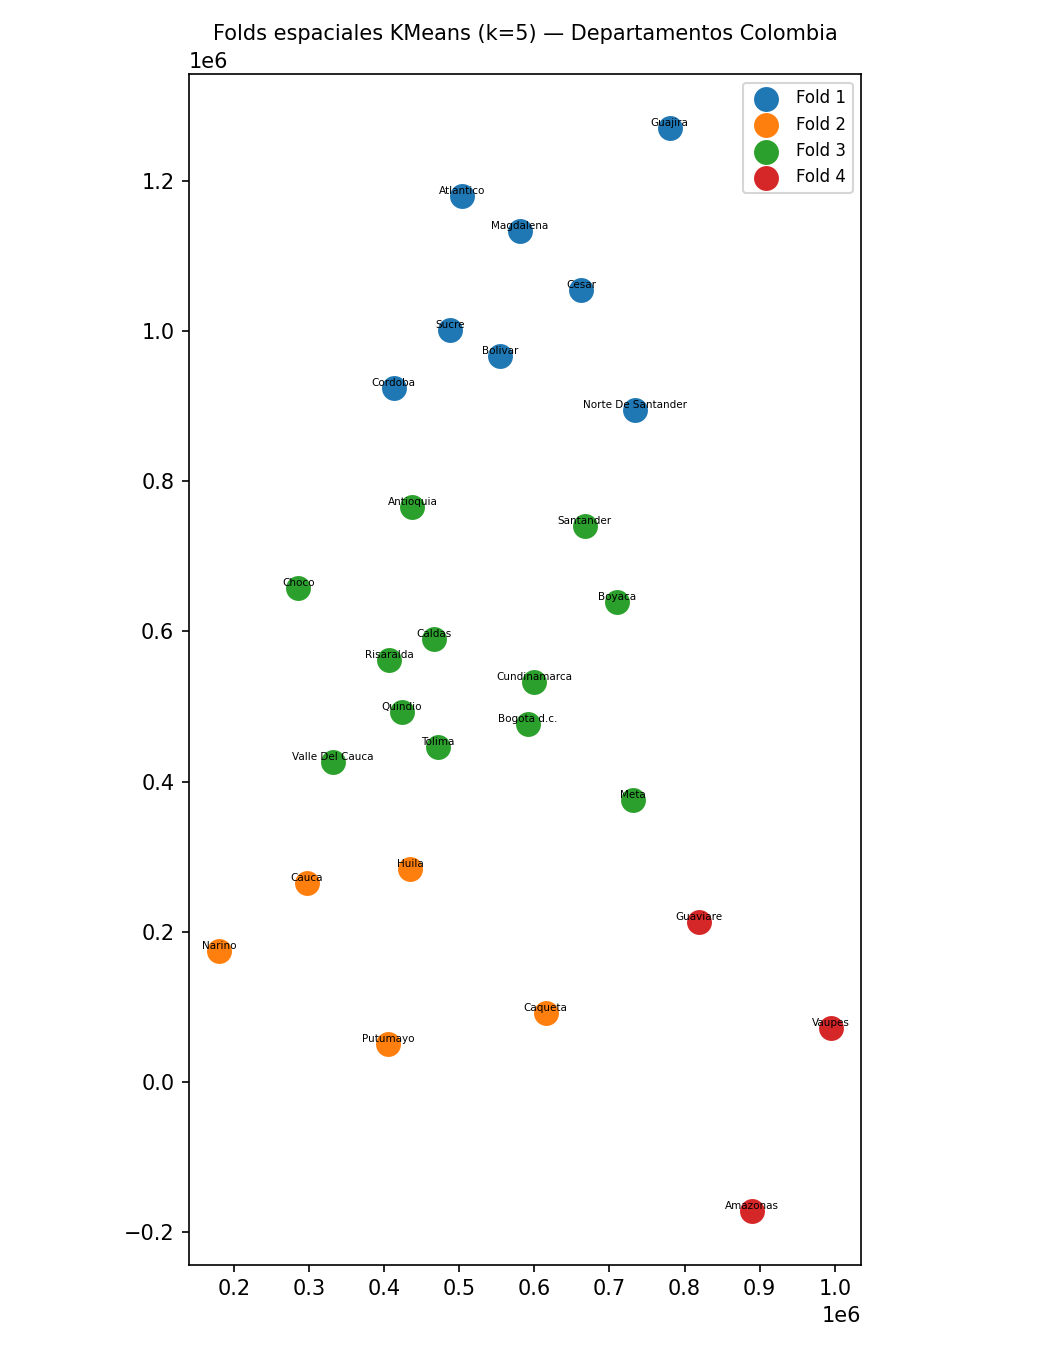

In [61]:
from PIL import Image
Image.open(f"{BASE_PATH}/spatial_folds_map.png")

El mapa de folds espaciales KMeans ($k=5$) ilustra la partición geográfica de los departamentos utilizada en la validación cruzada espacial. El **Fold 1** (azul) agrupa los departamentos de la región Caribe y norte del país —Atlántico, Magdalena, Cesar, Sucre, Bolívar, Córdoba, Guajira y Norte de Santander—, conformando un clúster geográficamente cohesivo de alta densidad poblacional y transmisión endémica de dengue en la franja costera norte. El **Fold 2** (naranja) reúne departamentos del suroccidente y sur del país —Cauca, Huila, Nariño, Caquetá y Putumayo—, caracterizados por su posición periférica, relieve montañoso y dinámica epidémica particular influenciada por factores ambientales del Pacífico y la Amazonia occidental. El **Fold 3** (verde) es el más heterogéneo del conjunto, abarcando el eje andino central y oriental —Antioquia, Chocó, Caldas, Risaralda, Quindío, Tolima, Valle del Cauca, Cundinamarca, Bogotá d.c., Boyacá, Santander y Meta—, que concentra la mayor parte de la población urbana del país y los departamentos de mayor incidencia acumulada histórica. El **Fold 4** (rojo) agrupa los departamentos amazónicos de menor densidad poblacional y mayor aislamiento geográfico —Amazonas, Vaupés y Guaviare—, que presentan las dinámicas epidémicas más irregulares y variables del sistema. La distribución espacial de los folds refleja que el algoritmo KMeans captura patrones geográficos interpretables —regiones naturales y corredores de transmisión— que corresponden a unidades epidemiológicas funcionalmente diferenciadas, validando la idoneidad de esta partición para evaluar la generalización espacial de los modelos.

## **7.5. Esquema de Validación Espacio-Temporal**

Esta sección define la estrategia de validación cruzada anidada (*Nested Cross-Validation*) para evaluar el modelo bajo un enfoque espacio-temporal estricto y robusto. Mediante las funciones `create_outer_folds` y `create_inner_folds`, el código fragmenta cronológicamente los datos en bloques externos de prueba (años 2022 a 2024) y bloques internos de validación (años 2019 a 2021) para simular escenarios reales de predicción a futuro. Finalmente, integra el estimador `LeaveOneGroupOut` de scikit-learn, configurando un esquema donde cada ciclo de optimización (*tuning*) cruza estas ventanas de tiempo con las regiones geográficas previas, garantizando que el algoritmo sea evaluado aislando grupos espaciales completos para medir su capacidad de generalización en territorios no observados.

In [35]:
def create_outer_folds(df, date_col="fecha_inicio"):
    folds = []
    for test_year in [2022, 2023, 2024]:
        train_df = df[df[date_col].dt.year <  test_year].copy()
        test_df  = df[df[date_col].dt.year == test_year].copy()
        folds.append({"test_year": test_year, "train_df": train_df, "test_df": test_df})
    return folds

def create_inner_folds(train_df, val_years=[2019, 2020, 2021]):
    inner_folds = []
    for val_year in val_years:
        inner_train = train_df[train_df["fecha_inicio"].dt.year <  val_year].copy()
        inner_val   = train_df[train_df["fecha_inicio"].dt.year == val_year].copy()
        inner_folds.append({"val_year": val_year,
                             "inner_train": inner_train,
                             "inner_val":   inner_val})
    return inner_folds

outer_folds = create_outer_folds(df)

LOGO = LeaveOneGroupOut()

print(f"Outer folds temporales: {len(outer_folds)}")
print(f"Inner folds temporales: 3 (2019, 2020, 2021)")
print(f"Folds espaciales: {N_SPATIAL_FOLDS}")
print(f"Total iteraciones tuning por trial: {3 * N_SPATIAL_FOLDS} (inner × spatial)")

Outer folds temporales: 3
Inner folds temporales: 3 (2019, 2020, 2021)
Folds espaciales: 5
Total iteraciones tuning por trial: 15 (inner × spatial)


## **7.6. Ventanas de Tiempo & Escalamiento**

Se reestructuran los datos en ventanas deslizantes tridimensionales y posteriormente se realiza una normalización estadística. La función `create_windows` utiliza tablas de pivote para transformar el DataFrame plano en tensores organizados por tiempo, nodos (departamentos) y características, generando secuencias históricas de entrenamiento (`window_size=12`) emparejadas con sus respectivos horizontes de predicción futura (`horizon=4`). Por otro lado, la función `scale_data` implementa un objeto `RobustScaler` que se ajusta exclusivamente con los datos de entrenamiento tras aplanar temporalmente las dimensiones, escalando las señales basándose en percentiles e rangos intercuartílicos para neutralizar el impacto de valores atípicos extremos antes de devolver los arreglos con su forma espacio-temporal original.

In [ ]:
def create_windows(df, features, target, window_size=12, horizon=4):
    pivot_features = []
    for feat in features:
        pivot = df.pivot_table(index="fecha_inicio", columns="departamento",
                               values=feat).sort_index()
        pivot_features.append(pivot.values)

    X_all = np.stack(pivot_features, axis=-1)  

    target_pivot = df.pivot_table(index="fecha_inicio", columns="departamento",
                                  values=target).sort_index()
    y_all  = target_pivot.values
    dates  = target_pivot.index.values

    X, y, base_dates = [], [], []
    for i in range(len(dates) - window_size - horizon + 1):
        X.append(X_all[i : i + window_size])
        y.append(y_all[i + window_size : i + window_size + horizon])
        base_dates.append(dates[i + window_size - 1])

    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32), np.array(base_dates)


def scale_data(X_train, X_val):
    scaler = RobustScaler()
    nf     = X_train.shape[-1]
    X_train_2d = X_train.reshape(-1, nf)
    scaler.fit(X_train_2d)
    X_train_sc = scaler.transform(X_train_2d).reshape(X_train.shape)
    X_val_sc   = scaler.transform(X_val.reshape(-1, nf)).reshape(X_val.shape)
    return X_train_sc, X_val_sc, scaler

## **7.7. Dataset, Early Stopping & Funciones de Entrenamiento**

Se definen los componentes esenciales para el ciclo de entrenamiento y control de optimización del modelo espacio-temporal. La clase `ConvLSTMDataset` reestructura los tensores de entrada para adaptarlos al formato convolucional de PyTorch, mientras que `EarlyStopping` monitorea la pérdida de validación para prevenir el sobreajuste interrumpiendo el proceso ante el estancamiento del aprendizaje. Por su parte, las funciones `train_one_epoch` y `validate_one_epoch` gestionan la propagación hacia adelante, el cálculo de gradientes con recorte de norma para estabilizar el entrenamiento, y la evaluación asincrónica optimizada en GPU mediante el uso de `non_blocking=True`.

In [ ]:
class ConvLSTMDataset(Dataset):

    def __init__(self, X, y):
        X_t = X.transpose(0, 1, 3, 2)          
        X_t = X_t[:, :, :, np.newaxis, :]      
        self.X = torch.tensor(X_t, dtype=torch.float32)
        self.y = torch.tensor(y,   dtype=torch.float32)

    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]


class EarlyStopping:
    def __init__(self, patience=20):
        self.patience  = patience
        self.best_loss = np.inf
        self.counter   = 0
        self.stop      = False
    def step(self, val_loss):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter   = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True


def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    for X_batch, y_batch in dataloader:
        X_batch = X_batch.to(device, non_blocking=True)
        y_batch = y_batch.to(device, non_blocking=True)
        optimizer.zero_grad()
        pred = model(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(dataloader)


def validate_one_epoch(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch = X_batch.to(device, non_blocking=True)
            y_batch = y_batch.to(device, non_blocking=True)
            pred = model(X_batch)
            loss = criterion(pred, y_batch)
            total_loss += loss.item()
    return total_loss / len(dataloader)

## **7.8. Métricas**

Se consolida el módulo de evaluación estadística del proyecto sobre los arreglos aplanados de los valores reales y predichos. Más allá de los indicadores tradicionales de magnitud de error como RMSE y MAE, se integra coeficientes hidrológicos y ecológicos avanzados como la eficiencia de Nash-Sutcliffe (`nse`) y el índice de Kling-Gupta (`kge`) para diagnosticar sesgos estructurales y variabilidad en la serie de tiempo. Asimismo, incorpora métricas de estricto control epidemiológico como el `rmse_top10`, el cual aísla los registros que superan el percentil 90 con el fin de cuantificar de forma específica el desempeño del modelo frente a picos extremos y brotes epidémicos severos de dengue.

In [57]:
def mape(y_true, y_pred, eps=1.0):
    return np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + eps))) * 100

def smape(y_true, y_pred, eps=1.0):
    num = np.abs(y_true - y_pred)
    den = (np.abs(y_true) + np.abs(y_pred)) / 2 + eps
    return np.mean(num / den) * 100

def nse(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / (ss_tot + 1e-10)

def kge(y_true, y_pred):
    r     = np.corrcoef(y_true, y_pred)[0, 1]
    alpha = np.std(y_pred) / (np.std(y_true) + 1e-10)
    beta  = np.mean(y_pred) / (np.mean(y_true) + 1e-10)
    return 1 - np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)

def skill_score(y_true, y_pred):
    mse_model = mean_squared_error(y_true, y_pred)
    mse_naive = mean_squared_error(y_true, np.full_like(y_true, np.mean(y_true)))
    return 1 - mse_model / (mse_naive + 1e-10)

def rmse_top10(y_true, y_pred, q=0.90):
    threshold = np.quantile(y_true, q)
    mask = y_true >= threshold
    if mask.sum() == 0:
        return np.nan
    return np.sqrt(mean_squared_error(y_true[mask], y_pred[mask]))

def pearson_r(y_true, y_pred):
    if np.std(y_true) < 1e-10 or np.std(y_pred) < 1e-10:
        return np.nan
    return np.corrcoef(y_true, y_pred)[0, 1]

def compute_all_metrics(y_true, y_pred, prefix=""):
    yt, yp = np.array(y_true).flatten(), np.array(y_pred).flatten()
    return {
        f"{prefix}RMSE":        np.sqrt(mean_squared_error(yt, yp)),
        f"{prefix}MAE":         mean_absolute_error(yt, yp),
        f"{prefix}MAPE":        mape(yt, yp),
        f"{prefix}sMAPE":       smape(yt, yp),
        f"{prefix}NSE":         nse(yt, yp),
        f"{prefix}KGE":         kge(yt, yp),
        f"{prefix}SkillScore":  skill_score(yt, yp),
        f"{prefix}RMSE_top10":  rmse_top10(yt, yp),
        f"{prefix}Pearson_r":   pearson_r(yt, yp),
        f"{prefix}Bias":        float(np.mean(yp - yt)),
    }

print("Métricas cargadas: RMSE, MAE, MAPE, sMAPE, NSE, KGE, SkillScore, RMSE_top10, Pearson_r, Bias")

Métricas cargadas: RMSE, MAE, MAPE, sMAPE, NSE, KGE, SkillScore, RMSE_top10, Pearson_r, Bias


## **7.9. Arquitectura ConvLSTM**

Se define la arquitectura completa del ConvLSTM mediante tres módulos apilados. El `ConvLSTMCell` implementa la celda recurrente convolucional que reemplaza las multiplicaciones matriciales estándar de una LSTM por convoluciones 2D —con kernel $(1 \times 3)$ para capturar vecindad espacial entre departamentos—, calculando las cuatro compuertas $(i, f, g, o)$ en una sola operación concatenada para eficiencia computacional y actualizando el estado de celda $c_t = f \odot c_{t-1} + i \odot g$ y el estado oculto $h_t = o \odot \tanh(c_t)$ preservando la estructura espacial en cada paso temporal. El `ConvLSTMLayer` envuelve la celda en un bucle temporal que procesa la secuencia paso a paso, retornando la secuencia completa en capas intermedias o únicamente el último estado oculto en la capa final. `SpatioTemporalConvLSTM` orquesta el flujo completo en modo **dual-branch**: proyecta linealmente los streams epidemiológico y climático a $d_{\text{hidden}}/2$ cada uno, los concatena en un tensor de forma $(B, T, d_{\text{hidden}}, 1, N)$ —donde la dimensión espacial se codifica como una cuadrícula $1 \times N$—, los procesa a través de $L$ capas `ConvLSTMLayer` apiladas, y aplica un decodificador convolucional 1D seguido de `BatchNorm` y una capa lineal final para producir predicciones de incidencia a un horizonte de cuatro semanas por departamento con forma $(B, H, N)$.

In [32]:
class ConvLSTMCell(nn.Module):

    def __init__(self, in_channels, hidden_channels, kernel_size=(1, 3), bias=True):
        super().__init__()
        self.hidden_channels = hidden_channels
        padding = (kernel_size[0] // 2, kernel_size[1] // 2)

        self.conv = nn.Conv2d(
            in_channels=in_channels + hidden_channels,
            out_channels=4 * hidden_channels,
            kernel_size=kernel_size,
            padding=padding,
            bias=bias
        )

    def forward(self, x, h_prev, c_prev):

        combined = torch.cat([x, h_prev], dim=1)  
        gates    = self.conv(combined)             

        i, f, g, o = torch.chunk(gates, 4, dim=1)
        i = torch.sigmoid(i)
        f = torch.sigmoid(f)
        g = torch.tanh(g)
        o = torch.sigmoid(o)

        c_next = f * c_prev + i * g
        h_next = o * torch.tanh(c_next)
        return h_next, c_next

    def init_hidden(self, batch_size, height, width, device):
        return (
            torch.zeros(batch_size, self.hidden_channels, height, width, device=device),
            torch.zeros(batch_size, self.hidden_channels, height, width, device=device)
        )


class ConvLSTMLayer(nn.Module):

    def __init__(self, in_channels, hidden_channels, kernel_size=(1, 3),
                 return_sequence=True, bias=True):
        super().__init__()
        self.cell            = ConvLSTMCell(in_channels, hidden_channels, kernel_size, bias)
        self.return_sequence = return_sequence

    def forward(self, x):
 
        B, T, C, H, W = x.shape
        h, c = self.cell.init_hidden(B, H, W, x.device)
        outputs = []
        for t in range(T):
            h, c = self.cell(x[:, t], h, c)
            outputs.append(h)

        if self.return_sequence:
            return torch.stack(outputs, dim=1)  # (B, T, C_hid, H, W)
        else:
            return h                             # (B, C_hid, H, W)


class SpatioTemporalConvLSTM(nn.Module):

    def __init__(self, num_nodes, n_features, hidden_channels=32, n_layers=2,
                 kernel_size=3, horizon=4, dropout=0.1,
                 n_epi=11, n_clim=18, dual_branch=True):
        super().__init__()
        self.num_nodes      = num_nodes
        self.horizon        = horizon
        self.dual_branch    = dual_branch
        self.n_epi          = n_epi
        self.n_clim         = n_clim
        self.hidden_channels = hidden_channels
        self.n_layers       = n_layers

        ks = (1, kernel_size)  

        if dual_branch:
           
            self.epi_proj  = nn.Linear(n_epi,  hidden_channels // 2)
            self.clim_proj = nn.Linear(n_clim, hidden_channels // 2)
            in_ch = hidden_channels   
        else:
            self.feat_proj = nn.Linear(n_features, hidden_channels)
            in_ch = hidden_channels

        self.convlstm_layers = nn.ModuleList()
        channels = in_ch
        for i in range(n_layers):
            return_seq = (i < n_layers - 1)   
            self.convlstm_layers.append(
                ConvLSTMLayer(channels, hidden_channels, kernel_size=ks,
                              return_sequence=return_seq)
            )
            channels = hidden_channels
        
        self.bn    = nn.BatchNorm2d(hidden_channels)
        self.drop  = nn.Dropout(dropout)

        self.decoder_conv = nn.Conv1d(hidden_channels, hidden_channels // 2,
                                      kernel_size=3, padding=1)
        self.decoder_bn   = nn.BatchNorm1d(hidden_channels // 2)
        self.fc_out       = nn.Linear(hidden_channels // 2, horizon)

    def forward(self, x):

        B, T, nF, H, W = x.shape

        if self.dual_branch:

            x_epi  = x[:, :, :self.n_epi,  :, :]   
            x_clim = x[:, :, self.n_epi:,  :, :]  

            def apply_proj(xt, proj):
                bt, tt, ff, hh, ww = xt.shape
                xt_r = xt.permute(0,1,3,4,2).reshape(-1, ff) 
                out  = proj(xt_r)                              
                return out.reshape(bt, tt, hh, ww, -1).permute(0,1,4,2,3)

            epi_emb  = F.relu(apply_proj(x_epi,  self.epi_proj))
            clim_emb = F.relu(apply_proj(x_clim, self.clim_proj))
            x_in = torch.cat([epi_emb, clim_emb], dim=2)  
        else:
            bt, tt, ff, hh, ww = x.shape
            x_r  = x.permute(0,1,3,4,2).reshape(-1, ff)
            x_pr = F.relu(self.feat_proj(x_r))
            x_in = x_pr.reshape(bt, tt, hh, ww, -1).permute(0,1,4,2,3)

        out = x_in
        for layer in self.convlstm_layers:
            out = layer(out)

        out = self.bn(out)              
        out = self.drop(out)
        out = out.squeeze(2)            

        out = F.relu(self.decoder_conv(out)) 
        out = self.decoder_bn(out)
        out = self.drop(out)

        out = out.permute(0, 2, 1)          
        out = self.fc_out(out)             
        out = out.permute(0, 2, 1)          

        return out

print("=" * 60)
print("ConvLSTM — Test de arquitectura")
print("=" * 60)
_B, _T, _F, _N = 4, 12, len(FEATURES), NUM_NODES
_x  = torch.randn(_B, _T, _F, 1, _N)
_m  = SpatioTemporalConvLSTM(
    num_nodes=_N, n_features=_F, hidden_channels=32, n_layers=2,
    kernel_size=3, horizon=4, dropout=0.1, n_epi=N_EPI, n_clim=N_CLIM,
    dual_branch=True
)
_out = _m(_x)
print(f"  Input  shape: {tuple(_x.shape)}")
print(f"  Output shape: {tuple(_out.shape)}  ← esperado ({_B}, 4, {_N})")
n_params = sum(p.numel() for p in _m.parameters() if p.requires_grad)
print(f"  Parámetros entrenables: {n_params:,}")
del _m, _x, _out
print("Arquitectura ConvLSTM definida correctamente.")

ConvLSTM — Test de arquitectura
  Input  shape: (4, 12, 29, 1, 32)
  Output shape: (4, 4, 32)  ← esperado (4, 4, 32)
  Parámetros entrenables: 51,620
Arquitectura ConvLSTM definida correctamente.


## **7.10. Optimización de Hiperparámetros (Optuna + Spatial-KFold × Inner Temporal)**

Aquí se define la función objetivo de Optuna para automatizar la optimización de hiperparámetros estructurales y de entrenamiento del transformador mediante un esquema de validación cruzada anidada. Para cada combinación de parámetros, se ejecuta un bucle doble que cruza los tres bloques temporales internos con los cinco pliegues geográficos (`LeaveOneGroupOut`), entrenando el modelo con los departamentos restantes para luego evaluar el RMSE promedio sobre las regiones y años dejados fuera, asegurando así una selección de parámetros robusta frente al sesgo espacio-temporal.

In [ ]:
ALL_OPTUNA_TRIALS    = []
ALL_SPATIAL_CV_FOLDS = []
ALL_RESIDUALS        = []
ALL_INFERENCE_TIME   = []
ALL_BEST_PARAMS      = []
ALL_RESULTS          = []
ALL_PREDICTIONS      = []
ALL_LOSSES           = []
ALL_SPATIAL_RESULTS  = []

TUNING_DF = df[df["fecha_inicio"].dt.year < 2022].copy()
INNER_FOLDS_TUNING = create_inner_folds(TUNING_DF, val_years=[2019, 2020, 2021])

print(f"Iteraciones por trial Optuna: {len(INNER_FOLDS_TUNING)} temporal × {N_SPATIAL_FOLDS} espacial = "
      f"{len(INNER_FOLDS_TUNING) * N_SPATIAL_FOLDS}")

current_seed = None 

In [ ]:
def objective(trial):

    window_size      = trial.suggest_categorical("window_size",      [8, 12, 16])
    learning_rate    = trial.suggest_float(      "learning_rate",    5e-4, 5e-3, log=True)
    batch_size       = trial.suggest_categorical("batch_size",       [16, 32])
    dropout          = trial.suggest_float(      "dropout",          0.0, 0.3, step=0.1)
    hidden_channels  = trial.suggest_categorical("hidden_channels",  [16, 32, 64])
    n_layers         = trial.suggest_int(        "n_layers",         1, 2)
    kernel_size      = trial.suggest_categorical("kernel_size",      [3, 5, 7])
    dual_branch      = trial.suggest_categorical("dual_branch",      [True, False])

    rmse_all = []

    for inner_fold in INNER_FOLDS_TUNING:
        inner_train = inner_fold["inner_train"]
        inner_val   = inner_fold["inner_val"]
        val_year    = inner_fold["val_year"]

        dept_groups = inner_train.drop_duplicates("departamento")[["departamento","spatial_fold"]]

        for held_fold_id in range(N_SPATIAL_FOLDS):
            train_depts_sp = dept_groups[dept_groups["spatial_fold"] != held_fold_id]["departamento"].tolist()
            val_depts_sp   = dept_groups[dept_groups["spatial_fold"] == held_fold_id]["departamento"].tolist()

            if not train_depts_sp or not val_depts_sp:
                continue

            sp_train = inner_train[inner_train["departamento"].isin(train_depts_sp)].copy()
            sp_val   = inner_val[  inner_val[  "departamento"].isin(val_depts_sp)  ].copy()

            if len(sp_train) == 0 or len(sp_val) == 0:
                continue

            try:
                X_train, y_train, _ = create_windows(sp_train, FEATURES, TARGET, window_size, 4)
                X_val,   y_val,   _ = create_windows(sp_val,   FEATURES, TARGET, window_size, 4)
            except Exception:
                continue

            if len(X_train) == 0 or len(X_val) == 0:
                continue

            X_train_sc, X_val_sc, _ = scale_data(X_train, X_val)

            n_nodes_train = X_train_sc.shape[2]
            ks = min(kernel_size, n_nodes_train)   
            if ks % 2 == 0:
                ks -= 1  
            ks = max(ks, 1)

            train_loader = DataLoader(
                ConvLSTMDataset(X_train_sc, y_train), batch_size=batch_size,
                shuffle=False, num_workers=4, pin_memory=True, persistent_workers=True
            )
            val_loader = DataLoader(
                ConvLSTMDataset(X_val_sc, y_val), batch_size=batch_size,
                shuffle=False, num_workers=4, pin_memory=True, persistent_workers=True
            )

            model = SpatioTemporalConvLSTM(
                num_nodes=n_nodes_train, n_features=len(FEATURES),
                hidden_channels=hidden_channels, n_layers=n_layers,
                kernel_size=ks, horizon=4, dropout=dropout,
                n_epi=N_EPI, n_clim=N_CLIM, dual_branch=dual_branch
            ).to(DEVICE)

            criterion      = nn.MSELoss()
            optimizer      = torch.optim.Adam(model.parameters(), lr=learning_rate)
            early_stopping = EarlyStopping(patience=10)

            for epoch in range(50):
                train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
                vl = validate_one_epoch(model, val_loader, criterion, DEVICE)
                early_stopping.step(vl)
                if early_stopping.stop:
                    break

            model.eval()
            preds_list, trues_list = [], []
            with torch.no_grad():
                for Xb, yb in val_loader:
                    pred = model(Xb.to(DEVICE))
                    preds_list.append(pred.cpu().numpy())
                    trues_list.append(yb.numpy())

            p    = np.concatenate(preds_list).flatten()
            t    = np.concatenate(trues_list).flatten()
            rmse = np.sqrt(mean_squared_error(t, p))
            rmse_all.append(rmse)

            ALL_SPATIAL_CV_FOLDS.append({
                "trial": trial.number, "seed": current_seed,
                "val_year": val_year, "held_spatial_fold": held_fold_id,
                "held_depts": str(val_depts_sp), "rmse": rmse
            })

    if not rmse_all:
        raise optuna.exceptions.TrialPruned()

    rmse_mean = float(np.mean(rmse_all))
    rmse_std  = float(np.std(rmse_all))

    ALL_OPTUNA_TRIALS.append({
        "trial": trial.number, "seed": current_seed,
        "window_size": window_size, "learning_rate": learning_rate,
        "batch_size": batch_size, "dropout": dropout,
        "hidden_channels": hidden_channels, "n_layers": n_layers,
        "kernel_size": kernel_size, "dual_branch": dual_branch,
        "rmse_mean": rmse_mean, "rmse_std": rmse_std
    })

    trial.set_user_attr("rmse_folds", rmse_all)
    trial.set_user_attr("rmse_std",   rmse_std)
    return rmse_mean

## **7.11. Train, Spatial-KFold en Test & Evaluación**

Se implementa el flujo de evaluación del modelo mediante un bucle iterativo sobre múltiples semillas experimentales, ejecutando una optimización de hiperparámetros con Optuna y un esquema de validación cruzada anidada (*Nested Spatial-KFold*). Para cada pliegue exterior, los datos se segmentan cronológicamente en conjuntos de entrenamiento, validación y prueba, escalando las ventanas temporales para alimentar la arquitectura espacio-temporal bajo un criterio de parada temprana (*Early Stopping*). Finalmente, se revierte la transformación logarítmica de las predicciones para calcular métricas globales y desagregadas por pliegues espaciales, almacenando de forma estructurada los tiempos de cómputo, residuos y errores por departamento.

In [ ]:
for seed in SEEDS:
    print("\n" + "="*110)
    print(f"  SEED {seed}")
    print("="*110)

    set_seed(seed)
    current_seed = seed

    print("\n[PASO 1] Optuna + Spatial-KFold — buscando mejores hiperparámetros...")
    sampler = optuna.samplers.TPESampler(seed=seed)
    study   = optuna.create_study(direction="minimize", sampler=sampler)
    study.optimize(objective, n_trials=N_OPTUNA_TRIALS, show_progress_bar=True)

    best_params = study.best_trial.params
    print(f"  ✓ Mejores hiperparámetros (seed {seed}):")
    for k, v in best_params.items():
        print(f"    {k}: {v}")

    pd.DataFrame([{"seed": seed, **best_params}]).to_csv(
        f"{BASE_PATH}/convlstm_best_params_seed_{seed}.csv", index=False)
    ALL_BEST_PARAMS.append({"seed": seed, **best_params})

    for outer_idx, outer_fold in enumerate(outer_folds):
        test_year = outer_fold["test_year"]
        print(f"\n{'='*110}")
        print(f"  [OUTER FOLD {outer_idx+1}/3]  Test year: {test_year}  |  Seed: {seed}")
        print(f"{'='*110}")

        outer_train_df = outer_fold["train_df"]
        final_test_df  = outer_fold["test_df"]

        window_size     = best_params["window_size"]
        hidden_channels = best_params["hidden_channels"]
        n_layers        = best_params["n_layers"]
        kernel_size     = best_params["kernel_size"]
        dual_branch     = best_params["dual_branch"]
        dropout         = best_params["dropout"]
        learning_rate   = best_params["learning_rate"]
        batch_size      = best_params["batch_size"]

        ks = min(kernel_size, NUM_NODES)
        if ks % 2 == 0:
            ks -= 1
        ks = max(ks, 1)

        val_year       = outer_train_df["fecha_inicio"].dt.year.max()
        final_train_df = outer_train_df[outer_train_df["fecha_inicio"].dt.year <  val_year]
        final_val_df   = outer_train_df[outer_train_df["fecha_inicio"].dt.year == val_year]

        print(f"  Entrenamiento: hasta {val_year-1} | Val: {val_year} | Test: {test_year}")

        X_train, y_train, train_dates = create_windows(final_train_df, FEATURES, TARGET, window_size, 4)
        X_val,   y_val,   val_dates   = create_windows(final_val_df,   FEATURES, TARGET, window_size, 4)
        X_test,  y_test,  test_dates  = create_windows(final_test_df,  FEATURES, TARGET, window_size, 4)

        X_train_sc, X_val_sc, scaler = scale_data(X_train, X_val)
        X_test_sc = scaler.transform(X_test.reshape(-1, X_test.shape[-1])).reshape(X_test.shape)

        print(f"  Shapes — Train: {X_train_sc.shape} | Val: {X_val_sc.shape} | Test: {X_test_sc.shape}")

        train_loader = DataLoader(ConvLSTMDataset(X_train_sc, y_train), batch_size=batch_size,
                                  shuffle=False, num_workers=8, pin_memory=True, persistent_workers=True)
        val_loader   = DataLoader(ConvLSTMDataset(X_val_sc,   y_val),   batch_size=batch_size,
                                  shuffle=False, num_workers=8, pin_memory=True, persistent_workers=True)
        test_loader  = DataLoader(ConvLSTMDataset(X_test_sc,  y_test),  batch_size=batch_size,
                                  shuffle=False, num_workers=8, pin_memory=True, persistent_workers=True)

        model = SpatioTemporalConvLSTM(
            num_nodes=NUM_NODES, n_features=len(FEATURES),
            hidden_channels=hidden_channels, n_layers=n_layers,
            kernel_size=ks, horizon=4, dropout=dropout,
            n_epi=N_EPI, n_clim=N_CLIM, dual_branch=dual_branch
        ).to(DEVICE)

        n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"  Parámetros entrenables: {n_params:,}")

        criterion        = nn.MSELoss()
        optimizer        = torch.optim.Adam(model.parameters(), lr=learning_rate)
        scheduler        = torch.optim.lr_scheduler.ReduceLROnPlateau(
                               optimizer, mode="min", factor=0.5, patience=10)
        early_stopping   = EarlyStopping(patience=20)
        best_model_state = None
        best_loss        = np.inf
        total_train_time = 0.0

        print(f"\n  Entrenando ConvLSTM (max 300 épocas, early stopping patience=20)...")
        print(f"  {'Época':>6} | {'Train Loss':>12} | {'Val Loss':>12} | {'ES Counter':>10}")
        print(f"  {'-'*55}")

        for epoch in range(300):
            t0         = time.time()
            train_loss = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
            val_loss   = validate_one_epoch(model, val_loader, criterion, DEVICE)
            scheduler.step(val_loss)
            total_train_time += time.time() - t0

            if epoch % 10 == 0 or epoch < 5:
                print(f"  {epoch+1:>6} | {train_loss:>12.6f} | {val_loss:>12.6f} | "
                      f"{early_stopping.counter:>10}/{early_stopping.patience}")

            ALL_LOSSES.append({
                "seed": seed, "outer_fold": outer_idx+1, "test_year": test_year,
                "epoch": epoch+1, "train_loss": train_loss, "val_loss": val_loss
            })

            if val_loss < best_loss:
                best_loss        = val_loss
                best_model_state = copy.deepcopy(model.state_dict())

            early_stopping.step(val_loss)
            if early_stopping.stop:
                print(f"  ► Early stopping en época {epoch+1} (best val_loss={best_loss:.6f})")
                break

        model.load_state_dict(best_model_state)
        print(f"  ✓ Entrenamiento completado — {total_train_time:.1f}s totales")

        torch.save(model.state_dict(),
                   f"{BASE_PATH}/convlstm_seed_{seed}_outer_fold_{outer_idx+1}.pt")

        model.eval()
        t_inf = time.time()
        predictions, targets = [], []
        with torch.no_grad():
            for Xb, yb in test_loader:
                pred = model(Xb.to(DEVICE))
                predictions.append(pred.cpu().numpy())
                targets.append(yb.numpy())
        inference_time = time.time() - t_inf

        predictions = np.concatenate(predictions)   # (S, H, N)
        targets     = np.concatenate(targets)       # (S, H, N)
        pred_real   = np.expm1(predictions)
        true_real   = np.expm1(targets)

        m_real = compute_all_metrics(true_real, pred_real, prefix="real_")
        m_log  = compute_all_metrics(targets,   predictions, prefix="log_")

        ALL_RESULTS.append({
            "seed": seed, "outer_fold": outer_idx+1, "test_year": test_year,
            "train_time": total_train_time, "inference_time": inference_time,
            **m_real, **m_log
        })
        ALL_INFERENCE_TIME.append({
            "seed": seed, "outer_fold": outer_idx+1, "test_year": test_year,
            "inference_time": inference_time, "train_time": total_train_time
        })

        print(f"\n  [MÉTRICAS GLOBALES TEST — escala real]")
        for k, v in m_real.items():
            print(f"    {k}: {v:.4f}")

        rows_pred = []
        for i in range(len(predictions)):
            for h in range(4):
                for node in range(NUM_NODES):
                    yt  = float(targets[i, h, node])
                    yp  = float(predictions[i, h, node])
                    ytr = float(true_real[i, h, node])
                    ypr = float(pred_real[i, h, node])
                    res = yt - yp
                    dept_name = idx_to_dept[node]
                    rows_pred.append({
                        "seed": seed, "outer_fold": outer_idx+1, "test_year": test_year,
                        "departamento": dept_name,
                        "spatial_fold": fold_map[dept_name],
                        "fecha_base": test_dates[i], "horizonte": h+1,
                        "y_true_log": yt, "y_pred_log": yp,
                        "y_true_real": ytr, "y_pred_real": ypr,
                        "residual": res, "abs_error": abs(res), "sq_error": res**2
                    })
                    ALL_RESIDUALS.append({
                        "seed": seed, "outer_fold": outer_idx+1, "test_year": test_year,
                        "departamento": dept_name,
                        "spatial_fold": fold_map[dept_name],
                        "fecha_base": test_dates[i], "horizonte": h+1,
                        "residual": res
                    })

        fold_pred_df = pd.DataFrame(rows_pred)
        ALL_PREDICTIONS.append(fold_pred_df)

        print(f"\n  [SPATIAL-KFOLD EN TEST] Métricas por fold espacial...")
        print(f"  {'Fold':>5} | {'Departamentos':40} | {'RMSE':>8} | {'MAE':>8} | "
              f"{'NSE':>8} | {'KGE':>8} | {'Pearson':>8}")
        print(f"  {'-'*100}")

        for sp_fold_id in range(N_SPATIAL_FOLDS):
            fold_dept_preds = fold_pred_df[fold_pred_df["spatial_fold"] == sp_fold_id]
            if len(fold_dept_preds) < 2:
                continue

            yt_sp = fold_dept_preds["y_true_real"].values
            yp_sp = fold_dept_preds["y_pred_real"].values
            m_sp  = compute_all_metrics(yt_sp, yp_sp)

            depts_in_fold = sorted(fold_dept_preds["departamento"].unique())
            depts_str     = ", ".join(depts_in_fold[:3])
            if len(depts_in_fold) > 3:
                depts_str += f" (+{len(depts_in_fold)-3})"

            m_sp.update({
                "seed": seed, "outer_fold": outer_idx+1, "test_year": test_year,
                "spatial_fold": sp_fold_id,
                "n_departamentos": len(depts_in_fold),
                "departamentos": str(depts_in_fold)
            })
            ALL_SPATIAL_RESULTS.append(m_sp)

            print(f"  {sp_fold_id:>5} | {depts_str:40} | {m_sp['RMSE']:>8.3f} | "
                  f"{m_sp['MAE']:>8.3f} | {m_sp['NSE']:>8.3f} | "
                  f"{m_sp['KGE']:>8.3f} | {m_sp['Pearson_r']:>8.3f}")

### ***7.11.1. Guardado de Resultados***

Se consolida toda la metadata, métricas e inferencias generadas durante el pipeline de experimentación mediante la conversión de las listas globales estructuradas en estructuras de datos de pandas. Al exportar estos registros a archivos individuales en formato CSV, la celda asegura la trazabilidad y reproducibilidad del estudio, almacenando de forma organizada desde el historial de pérdidas de entrenamiento y los hiperparámetros óptimos seleccionados por Optuna, hasta las predicciones puntuales, los tiempos de cómputo y los residuos desagregados por departamento para su posterior análisis o auditoría estadística.

In [ ]:
results_df          = pd.DataFrame(ALL_RESULTS)
predictions_df      = pd.concat(ALL_PREDICTIONS, axis=0).reset_index(drop=True)
losses_df           = pd.DataFrame(ALL_LOSSES)
best_params_df      = pd.DataFrame(ALL_BEST_PARAMS)
optuna_trials_df    = pd.DataFrame(ALL_OPTUNA_TRIALS)
spatial_cv_folds_df = pd.DataFrame(ALL_SPATIAL_CV_FOLDS)
inference_df        = pd.DataFrame(ALL_INFERENCE_TIME)
residuals_df        = pd.DataFrame(ALL_RESIDUALS)
spatial_results_df  = pd.DataFrame(ALL_SPATIAL_RESULTS)

results_df.to_csv(         f"{BASE_PATH}/convlstm_results.csv",              index=False)
predictions_df.to_csv(     f"{BASE_PATH}/convlstm_predictions.csv",          index=False)
losses_df.to_csv(          f"{BASE_PATH}/convlstm_training_history.csv",     index=False)
best_params_df.to_csv(     f"{BASE_PATH}/convlstm_best_params.csv",          index=False)
optuna_trials_df.to_csv(   f"{BASE_PATH}/convlstm_optuna_trials.csv",        index=False)
spatial_cv_folds_df.to_csv(f"{BASE_PATH}/convlstm_spatial_cv_folds.csv",     index=False)
inference_df.to_csv(       f"{BASE_PATH}/convlstm_inference_time.csv",       index=False)
residuals_df.to_csv(       f"{BASE_PATH}/convlstm_residuals.csv",            index=False)
spatial_results_df.to_csv( f"{BASE_PATH}/convlstm_spatial_fold_results.csv", index=False)

print("Archivos guardados en:", BASE_PATH)
print("\nResumen global de resultados:")
cols_show = [c for c in results_df.columns if c.startswith("real_")]
print(results_df[["seed","test_year"] + cols_show].to_string(index=False))

## **7.12. Evaluación**

Se cargan desde el almacenamiento local los archivos CSV que contienen las métricas de rendimiento, las series de predicciones temporales y el historial de entrenamiento guardados previamente. 

In [16]:
BASE_PATH = "/home/moon/DEEP/PF/PF_DG/MODELOS/ConvLSTM_CV"
results_df         = pd.read_csv(f"{BASE_PATH}/convlstm_results.csv")
predictions_df     = pd.read_csv(f"{BASE_PATH}/convlstm_predictions.csv")
residuals_df       = pd.read_csv(f"{BASE_PATH}/convlstm_residuals.csv")
losses_df          = pd.read_csv(f"{BASE_PATH}/convlstm_training_history.csv")
spatial_results_df = pd.read_csv(f"{BASE_PATH}/convlstm_spatial_fold_results.csv")
print("Datos cargados.")
print("  results_df shape:",         results_df.shape)
print("  predictions_df shape:",     predictions_df.shape)
print("  spatial_results_df shape:", spatial_results_df.shape)

Datos cargados.
  results_df shape: (9, 25)
  predictions_df shape: (40704, 14)
  spatial_results_df shape: (36, 16)


### ***7.12.1. Métricas Globales & por Fold Espacial***

In [17]:
metric_cols_real = [c for c in results_df.columns if c.startswith("real_")]
metric_cols_log  = [c for c in results_df.columns if c.startswith("log_")]

print("=== MÉTRICAS GLOBALES (Media ± STD sobre seeds) ===")
for col in metric_cols_real:
    vals = results_df[col].dropna().values
    if len(vals) < 2: continue
    m   = np.mean(vals)
    sem = st.sem(vals)
    ci  = st.t.interval(0.95, df=len(vals)-1, loc=m, scale=sem)
    print(f"  {col:25}: {m:.4f} ± {np.std(vals):.4f}  IC95%: [{ci[0]:.4f}, {ci[1]:.4f}]")

=== MÉTRICAS GLOBALES (Media ± STD sobre seeds) ===
  real_RMSE                : 4.6362 ± 1.7491  IC95%: [3.2102, 6.0622]
  real_MAE                 : 2.5994 ± 1.3287  IC95%: [1.5162, 3.6827]
  real_MAPE                : 32.6815 ± 6.0975  IC95%: [27.7103, 37.6527]
  real_sMAPE               : 36.2084 ± 8.5544  IC95%: [29.2341, 43.1828]
  real_NSE                 : 0.5089 ± 0.1265  IC95%: [0.4058, 0.6121]
  real_KGE                 : 0.4413 ± 0.1880  IC95%: [0.2880, 0.5945]
  real_SkillScore          : 0.5089 ± 0.1265  IC95%: [0.4058, 0.6121]
  real_RMSE_top10          : 12.4064 ± 4.1509  IC95%: [9.0222, 15.7906]
  real_Pearson_r           : 0.8319 ± 0.0208  IC95%: [0.8150, 0.8489]
  real_Bias                : -2.0127 ± 1.3348  IC95%: [-3.1009, -0.9244]


Las métricas globales en escala real muestran una correlación lineal alta ($\rho = 0.8319$), respaldada por un NSE de $0.5089$ y un KGE de $0.4413$ que confirman la capacidad del modelo para superar la media histórica como predictor basal. No obstante, el error absoluto medio (MAE) de $2.59$ casos convive con un error relativo (sMAPE) del $36.21\%$, el cual se acentúa notablemente al evaluar los picos epidemiológicos (RMSE_top10 = $12.41$). Finalmente, el sesgo negativo persistente (Bias = $-2.01$) revela una tendencia estructural del modelo a subestimar el volumen total de casos de dengue, especialmente en los departamentos con mayor carga de incidencia.


=== MÉTRICAS POR FOLD ESPACIAL ===
                  RMSE                 MAE                 NSE                 KGE           SkillScore           Pearson_r                Bias          
                  mean       std      mean       std      mean       std      mean       std       mean       std      mean       std      mean       std
spatial_fold                                                                                                                                             
1             2.818426  0.937486  2.045554  0.670659  0.308041  0.185797  0.450739  0.166076   0.308041  0.185797  0.808170  0.045098 -1.765246  0.872636
2             4.274812  3.624100  2.780083  2.331314  0.489089  0.097208  0.496935  0.157200   0.489089  0.097208  0.828291  0.040402 -2.045559  2.168754
3             3.830635  3.005369  2.192415  1.922907  0.606320  0.197873  0.547626  0.216905   0.606320  0.197873  0.876846  0.055061 -1.832447  1.963677
4             7.657579  1.758017  4.8430

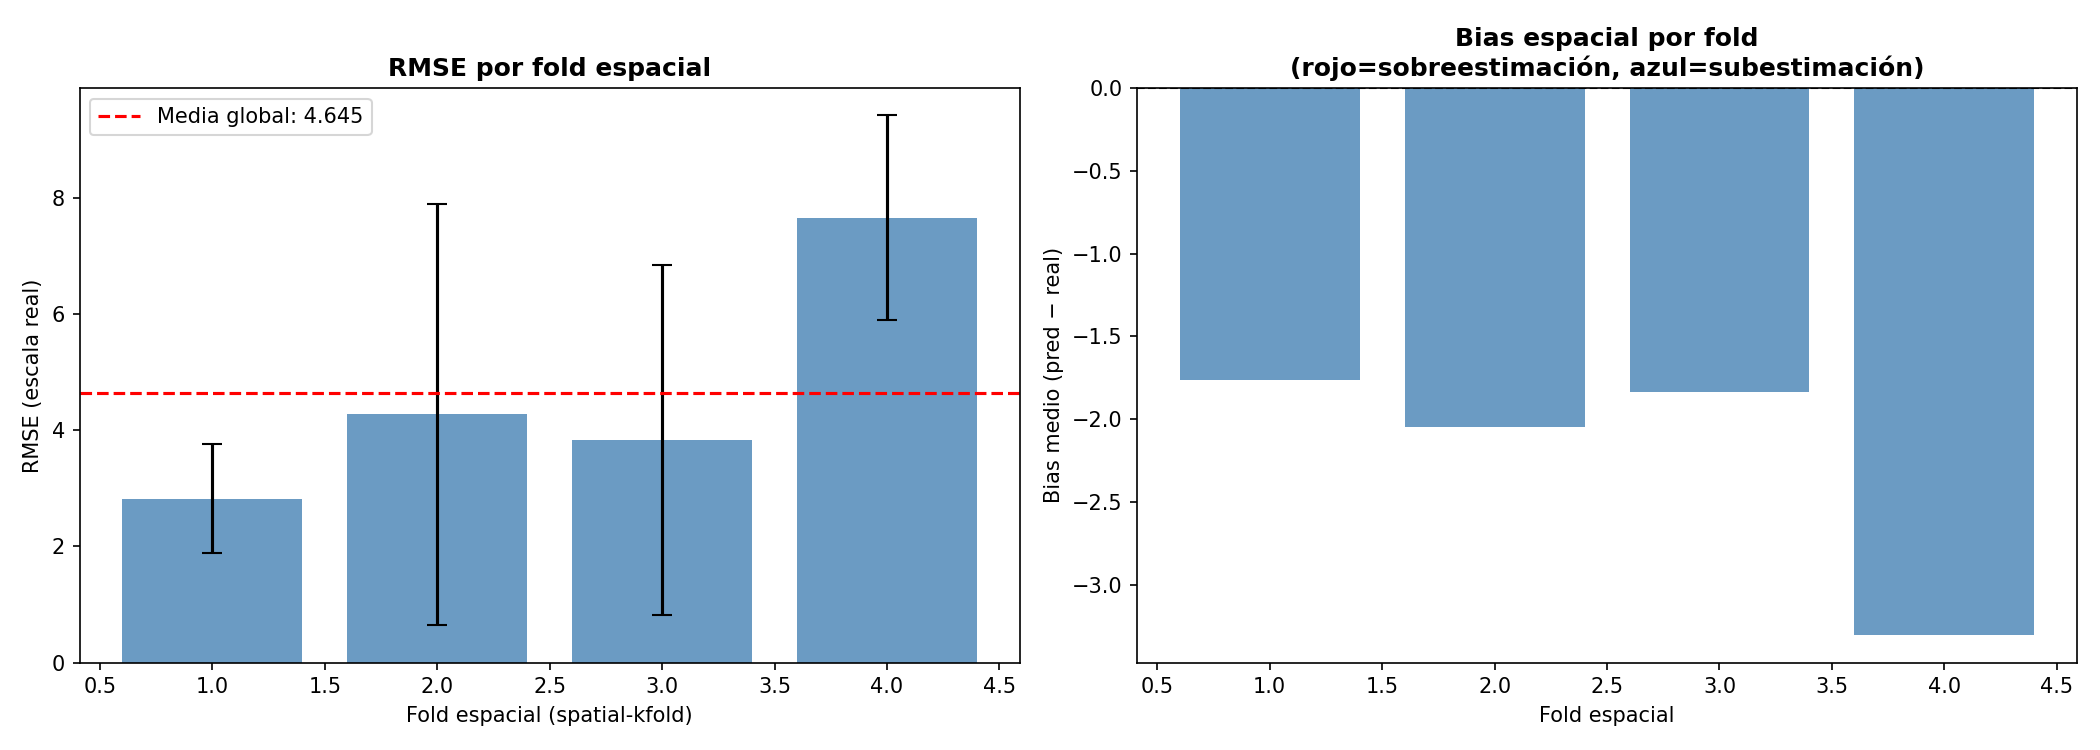

In [18]:
print("\n=== MÉTRICAS POR FOLD ESPACIAL ===")
sp_summary = (
    spatial_results_df
    .groupby("spatial_fold")[["RMSE","MAE","NSE","KGE","SkillScore","Pearson_r","Bias"]]
    .agg(["mean","std"])
)
print(sp_summary.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sp_rmse     = spatial_results_df.groupby("spatial_fold")["RMSE"].mean()
sp_rmse_std = spatial_results_df.groupby("spatial_fold")["RMSE"].std()
axes[0].bar(sp_rmse.index, sp_rmse.values, yerr=sp_rmse_std.values,
            color="steelblue", alpha=0.8, capsize=5)
axes[0].set_xlabel("Fold espacial (spatial-kfold)")
axes[0].set_ylabel("RMSE (escala real)")
axes[0].set_title("RMSE por fold espacial", fontweight="bold")
axes[0].axhline(spatial_results_df["RMSE"].mean(), color="red", linestyle="--",
                label=f"Media global: {spatial_results_df['RMSE'].mean():.3f}")
axes[0].legend()

sp_bias      = spatial_results_df.groupby("spatial_fold")["Bias"].mean()
colors_bias  = ["tomato" if b > 0 else "steelblue" for b in sp_bias.values]
axes[1].bar(sp_bias.index, sp_bias.values, color=colors_bias, alpha=0.8)
axes[1].axhline(0, color="black", linestyle="--", linewidth=1.0)
axes[1].set_xlabel("Fold espacial")
axes[1].set_ylabel("Bias medio (pred − real)")
axes[1].set_title("Bias espacial por fold\n(rojo=sobreestimación, azul=subestimación)",
                  fontweight="bold")

plt.tight_layout()
plt.savefig(f"{BASE_PATH}/convlstm_spatial_fold_metrics.png", dpi=150)
plt.show()

from PIL import Image
Image.open(f"{BASE_PATH}/convlstm_spatial_fold_metrics.png")

El análisis discriminado por pliegues espaciales confirma que el rendimiento del modelo exhibe una marcada heterogeneidad geográfica, alcanzando su desempeño óptimo en el pliegue 3 con el NSE ($0.61$) y Pearson ($\rho = 0.88$) más altos de la validación. En contraste, el pliegue 4 se consolida como la región más crítica del sistema, duplicando holgadamente el error global promedio con un RMSE de $7.66$ y un sesgo negativo pronunciado de $-3.30$ casos de dengue. Esta degradación del error y del estadístico KGE ($0.29$) en el pliegue 4 se asocia directamente con la dificultad sistemática del modelo para asimilar y predecir la magnitud real de los brotes agudos y picos epidémicos intensos presentes en esos departamentos específicos.

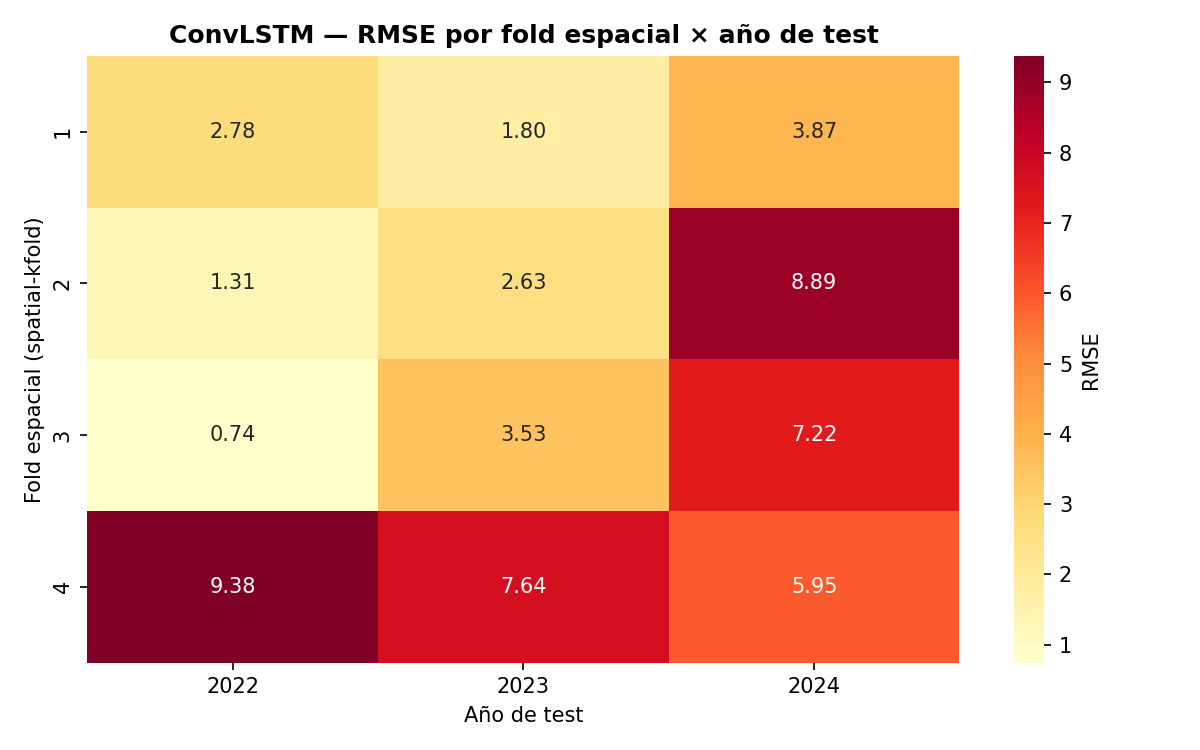

In [19]:
pivot_sp_rmse = spatial_results_df.groupby(["spatial_fold","test_year"])["RMSE"].mean().unstack()

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot_sp_rmse, ax=ax, cmap="YlOrRd", annot=True, fmt=".2f",
            cbar_kws={"label": "RMSE"})
ax.set_title("ConvLSTM — RMSE por fold espacial × año de test", fontweight="bold")
ax.set_xlabel("Año de test")
ax.set_ylabel("Fold espacial (spatial-kfold)")
plt.tight_layout()
plt.savefig(f"{BASE_PATH}/convlstm_spatial_fold_heatmap.png", dpi=150)
plt.show()

from PIL import Image
Image.open(f"{BASE_PATH}/convlstm_spatial_fold_heatmap.png")

La evaluación cruzada por año de prueba evidencia la compleja interacción espacio-temporal del dengue, destacando un incremento drástico del error general durante el año 2024 debido a la intensificación de picos epidémicos atípicos. Mientras que los pliegues espaciales 2 y 3 exhiben un comportamiento altamente controlado en escenarios de baja transmisión como 2022 ($RMSE = 1.31$ y $0.74$, respectivamente), sus métricas se degradan severamente en 2024 al alcanzar un $RMSE$ de $8.89$ y $7.22$. En contraposición, el pliegue 4 se consolida como un desafío estructural continuo e independiente del comportamiento anual, registrando sus mayores desajustes predictivos en el año 2022 ($RMSE = 9.38$) y manteniendo errores crónicamente elevados a lo largo de todo el horizonte temporal analizado.

### ***7.12.2. Métricas Globales por Seed y Año***

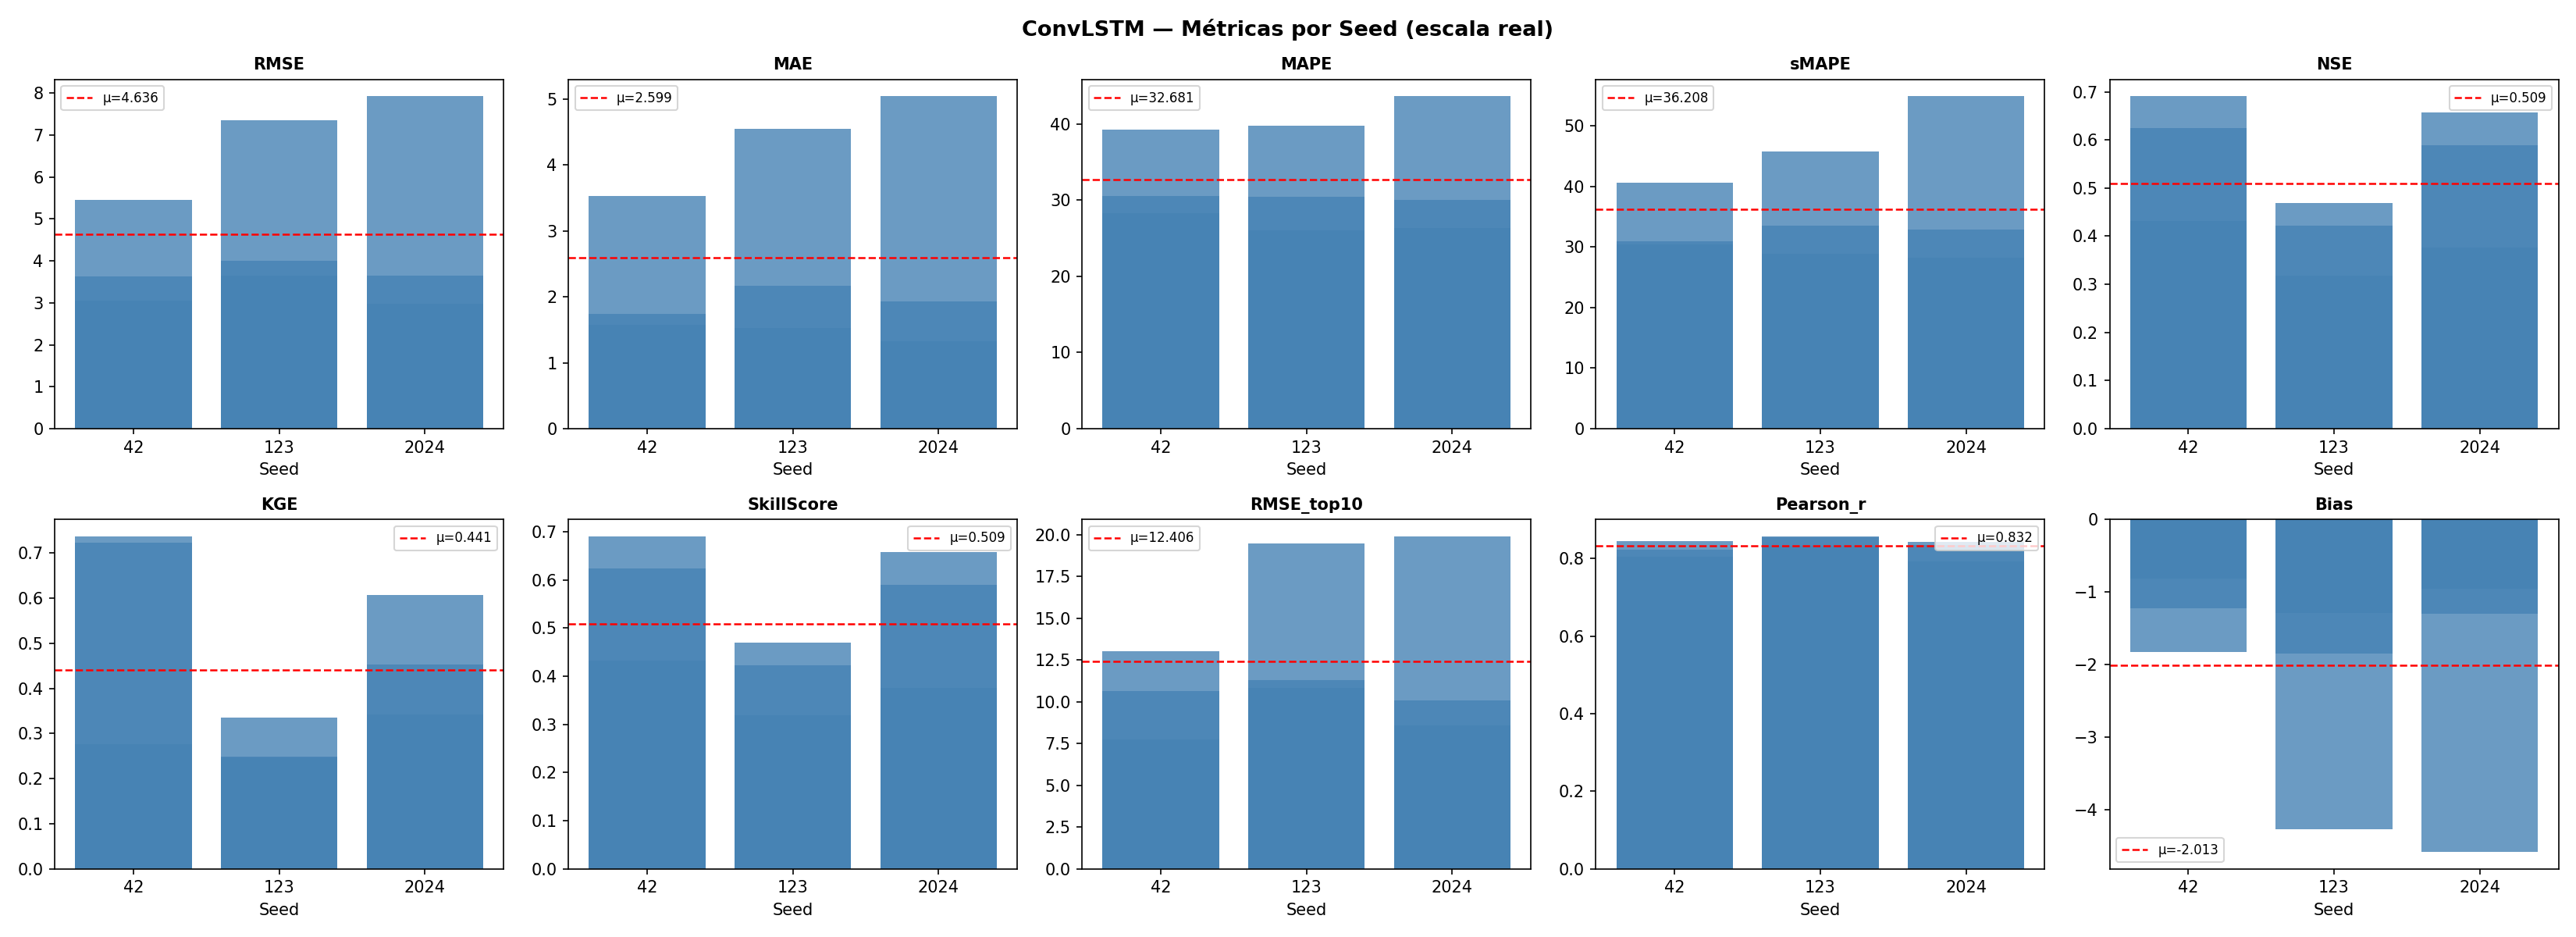

In [20]:
metric_names = [c.replace("real_","") for c in metric_cols_real]

fig, axes = plt.subplots(2, 5, figsize=(22, 8))
axes = axes.flatten()
for ax, col, name in zip(axes, metric_cols_real, metric_names):
    vals = results_df[col].values
    ax.bar([str(s) for s in results_df["seed"]], vals, color="steelblue", alpha=0.8)
    ax.set_title(name, fontsize=10, fontweight="bold")
    ax.set_xlabel("Seed")
    ax.axhline(np.mean(vals), color="red", linestyle="--", linewidth=1.2,
               label=f"μ={np.mean(vals):.3f}")
    ax.legend(fontsize=8)
plt.suptitle("ConvLSTM — Métricas por Seed (escala real)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{BASE_PATH}/convlstm_metrics_by_seed.png", dpi=150)
plt.show()

from PIL import Image
Image.open(f"{BASE_PATH}/convlstm_metrics_by_seed.png")

El análisis por semilla aleatoria del modelo **ConvLSTM** revela una arquitectura con comportamiento
reproducible en sus métricas de ajuste global, donde indicadores como **Pearson_r** (μ = 0.832),
**NSE** (μ = 0.509) y **SkillScore** (μ = 0.509) presentan variaciones mínimas entre las tres
ejecuciones, confirmando que la red converge a soluciones estructuralmente estables con independencia
de la inicialización de sus pesos. No obstante, la semilla **2024** concentra la mayor complejidad
predictiva, registrando los valores más elevados de error en **RMSE** (≈ 8.0), **MAE** (≈ 5.0) y
**MAPE** (≈ 40%), lo que sugiere que condiciones de alta variabilidad en los datos de entrada
amplifican la sensibilidad estocástica del modelo. Esta degradación es consistente con el
comportamiento del **RMSE_top10** (μ = 12.406), cuyo incremento hacia la semilla 2024 evidencia
una dificultad estructural del modelo para capturar adecuadamente los picos extremos de la
distribución. Finalmente, el **Bias** sistemáticamente negativo (μ = −2.013) y la contracción del
**KGE** en la semilla 123 indican que, si bien la arquitectura garantiza alta reproducibilidad
global, la calibración fina del volumen total y la simetría de los residuos permanecen como las
dimensiones más vulnerables frente a la inicialización aleatoria.

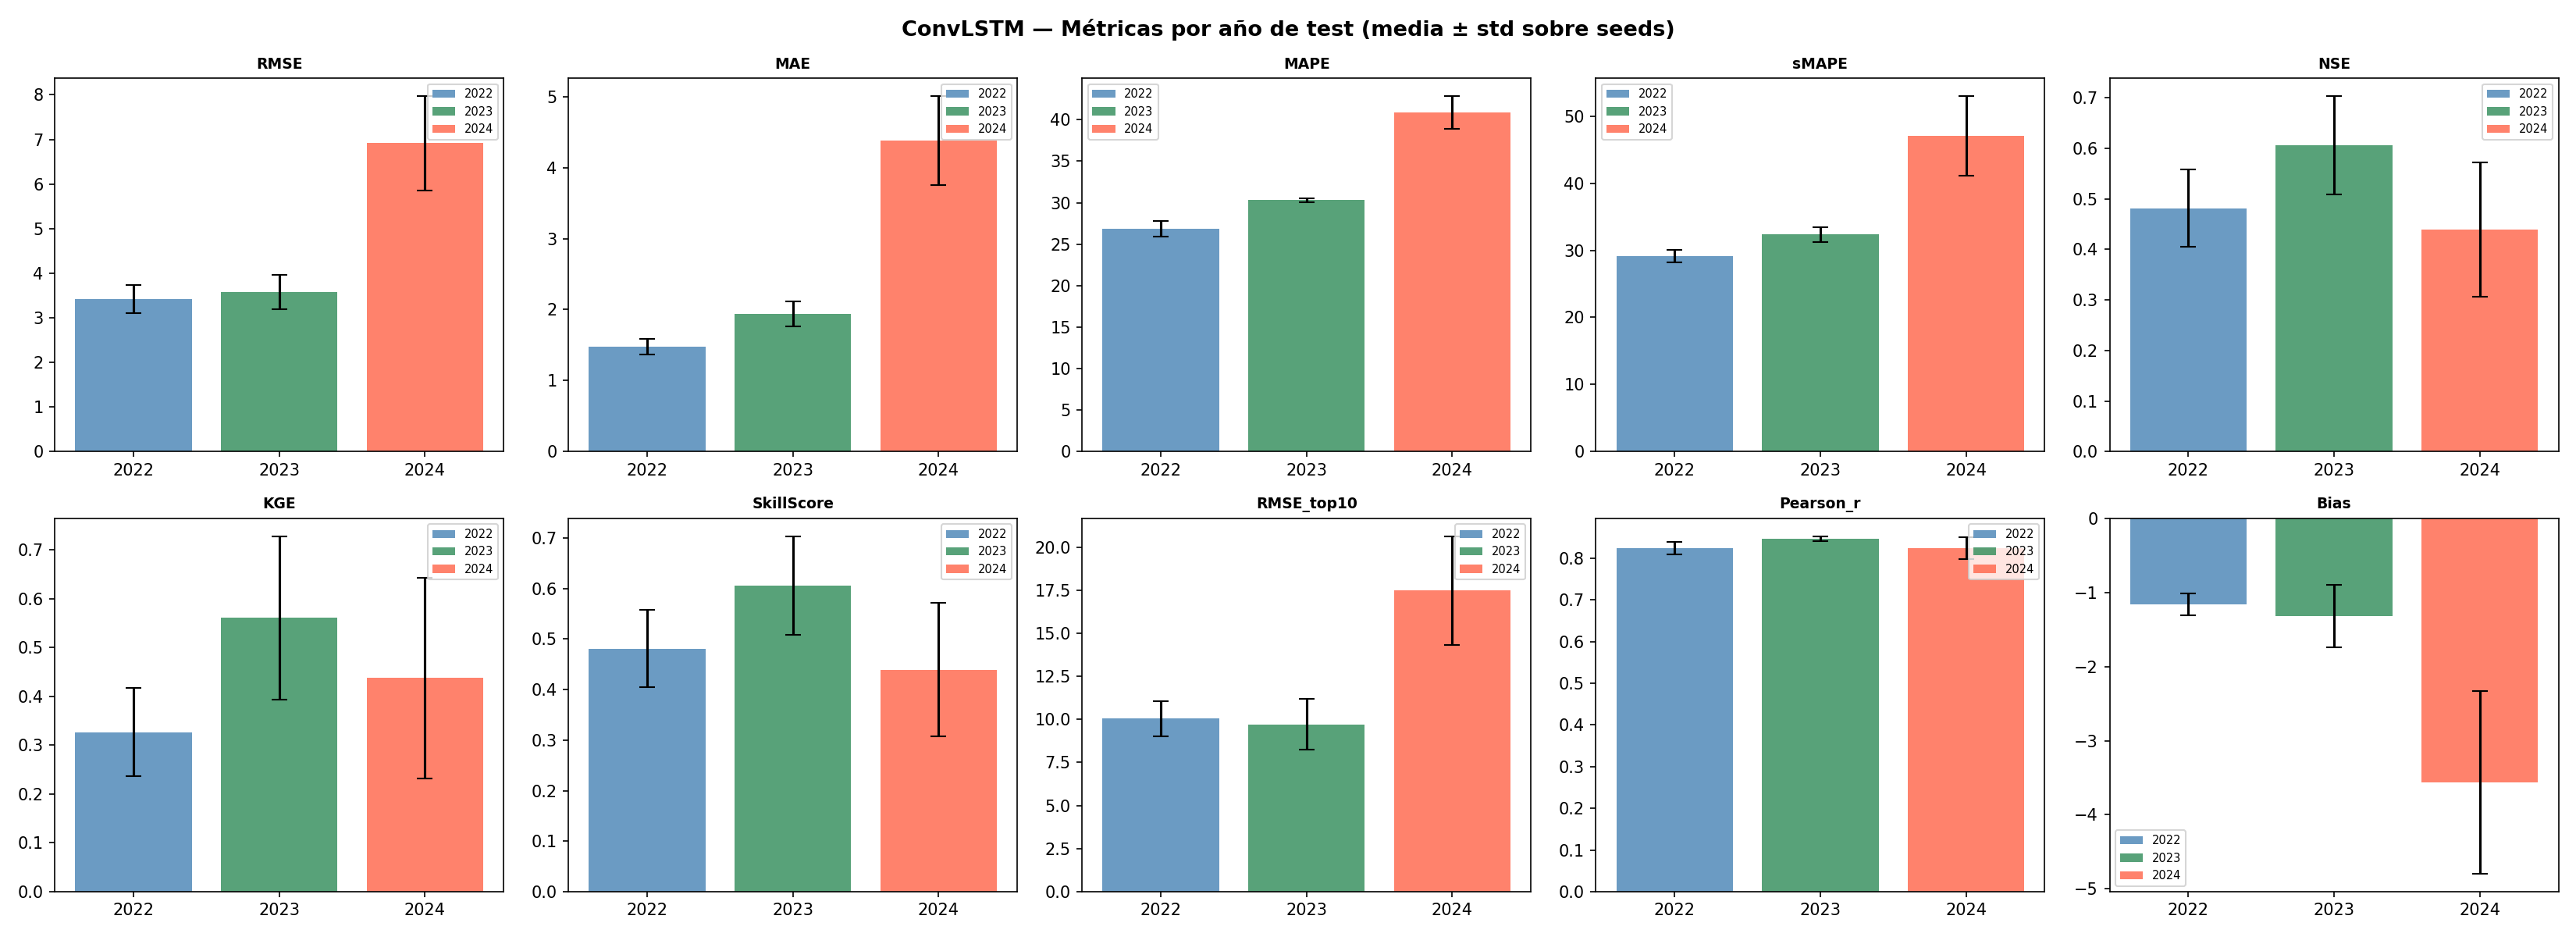

In [21]:
fig, axes = plt.subplots(2, 5, figsize=(22, 8))
axes = axes.flatten()
years  = sorted(results_df["test_year"].unique())
colors = ["steelblue","seagreen","tomato"]
for ax, col, name in zip(axes, metric_cols_real, metric_names):
    for year, color in zip(years, colors):
        sub = results_df[results_df["test_year"]==year][col].values
        ax.bar([str(year)], np.mean(sub), color=color, alpha=0.8,
               yerr=np.std(sub), capsize=5, label=str(year))
    ax.set_title(name, fontsize=9, fontweight="bold")
    ax.legend(fontsize=7)
plt.suptitle("ConvLSTM — Métricas por año de test (media ± std sobre seeds)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{BASE_PATH}/convlstm_metrics_by_year.png", dpi=150)
plt.show()

from PIL import Image
Image.open(f"{BASE_PATH}/convlstm_metrics_by_year.png")

El análisis temporal del modelo **ConvLSTM** por año de prueba evidencia una degradación
progresiva del rendimiento predictivo, donde el año **2024** concentra el mayor deterioro
en todas las métricas de error: **RMSE** (≈ 7.0), **MAE** (≈ 4.5) y **MAPE** (≈ 40%),
valores que prácticamente duplican los registrados en 2022 y 2023, señalando que el modelo
enfrenta condiciones de distribución fuera de su régimen de entrenamiento. Esta ruptura
estructural se confirma en los indicadores de bondad de ajuste, donde **NSE** y **SkillScore**
caen notablemente en 2024 (≈ 0.43 y ≈ 0.44 respectivamente) frente al mejor desempeño
observado en **2023**, año en que el modelo alcanzó su mayor capacidad discriminativa con
**KGE** ≈ 0.57 y **SkillScore** ≈ 0.61. La ampliación de las barras de error en 2024,
particularmente pronunciada en  **Bias** y **RMSE_top10** (≈ 17.5), refleja una
alta inestabilidad entre semillas que contrasta con la robustez exhibida en años anteriores,
sugiriendo que la variabilidad extrema del año 2024 supera la capacidad de generalización
aprendida por la arquitectura. Finalmente, el **Bias** sistemáticamente negativo que se
profundiza en 2024 (llegando hasta −5 en el peor escenario) confirma una subestimación
crónica del volumen de casos, lo que indica que el modelo no logra capturar la magnitud
de los picos epidémicos más recientes y demanda una reentrenamiento o actualización con
datos del ciclo epidémico actual.

### ***7.12.3. Predicciones, Residuos y Curvas de Pérdida***

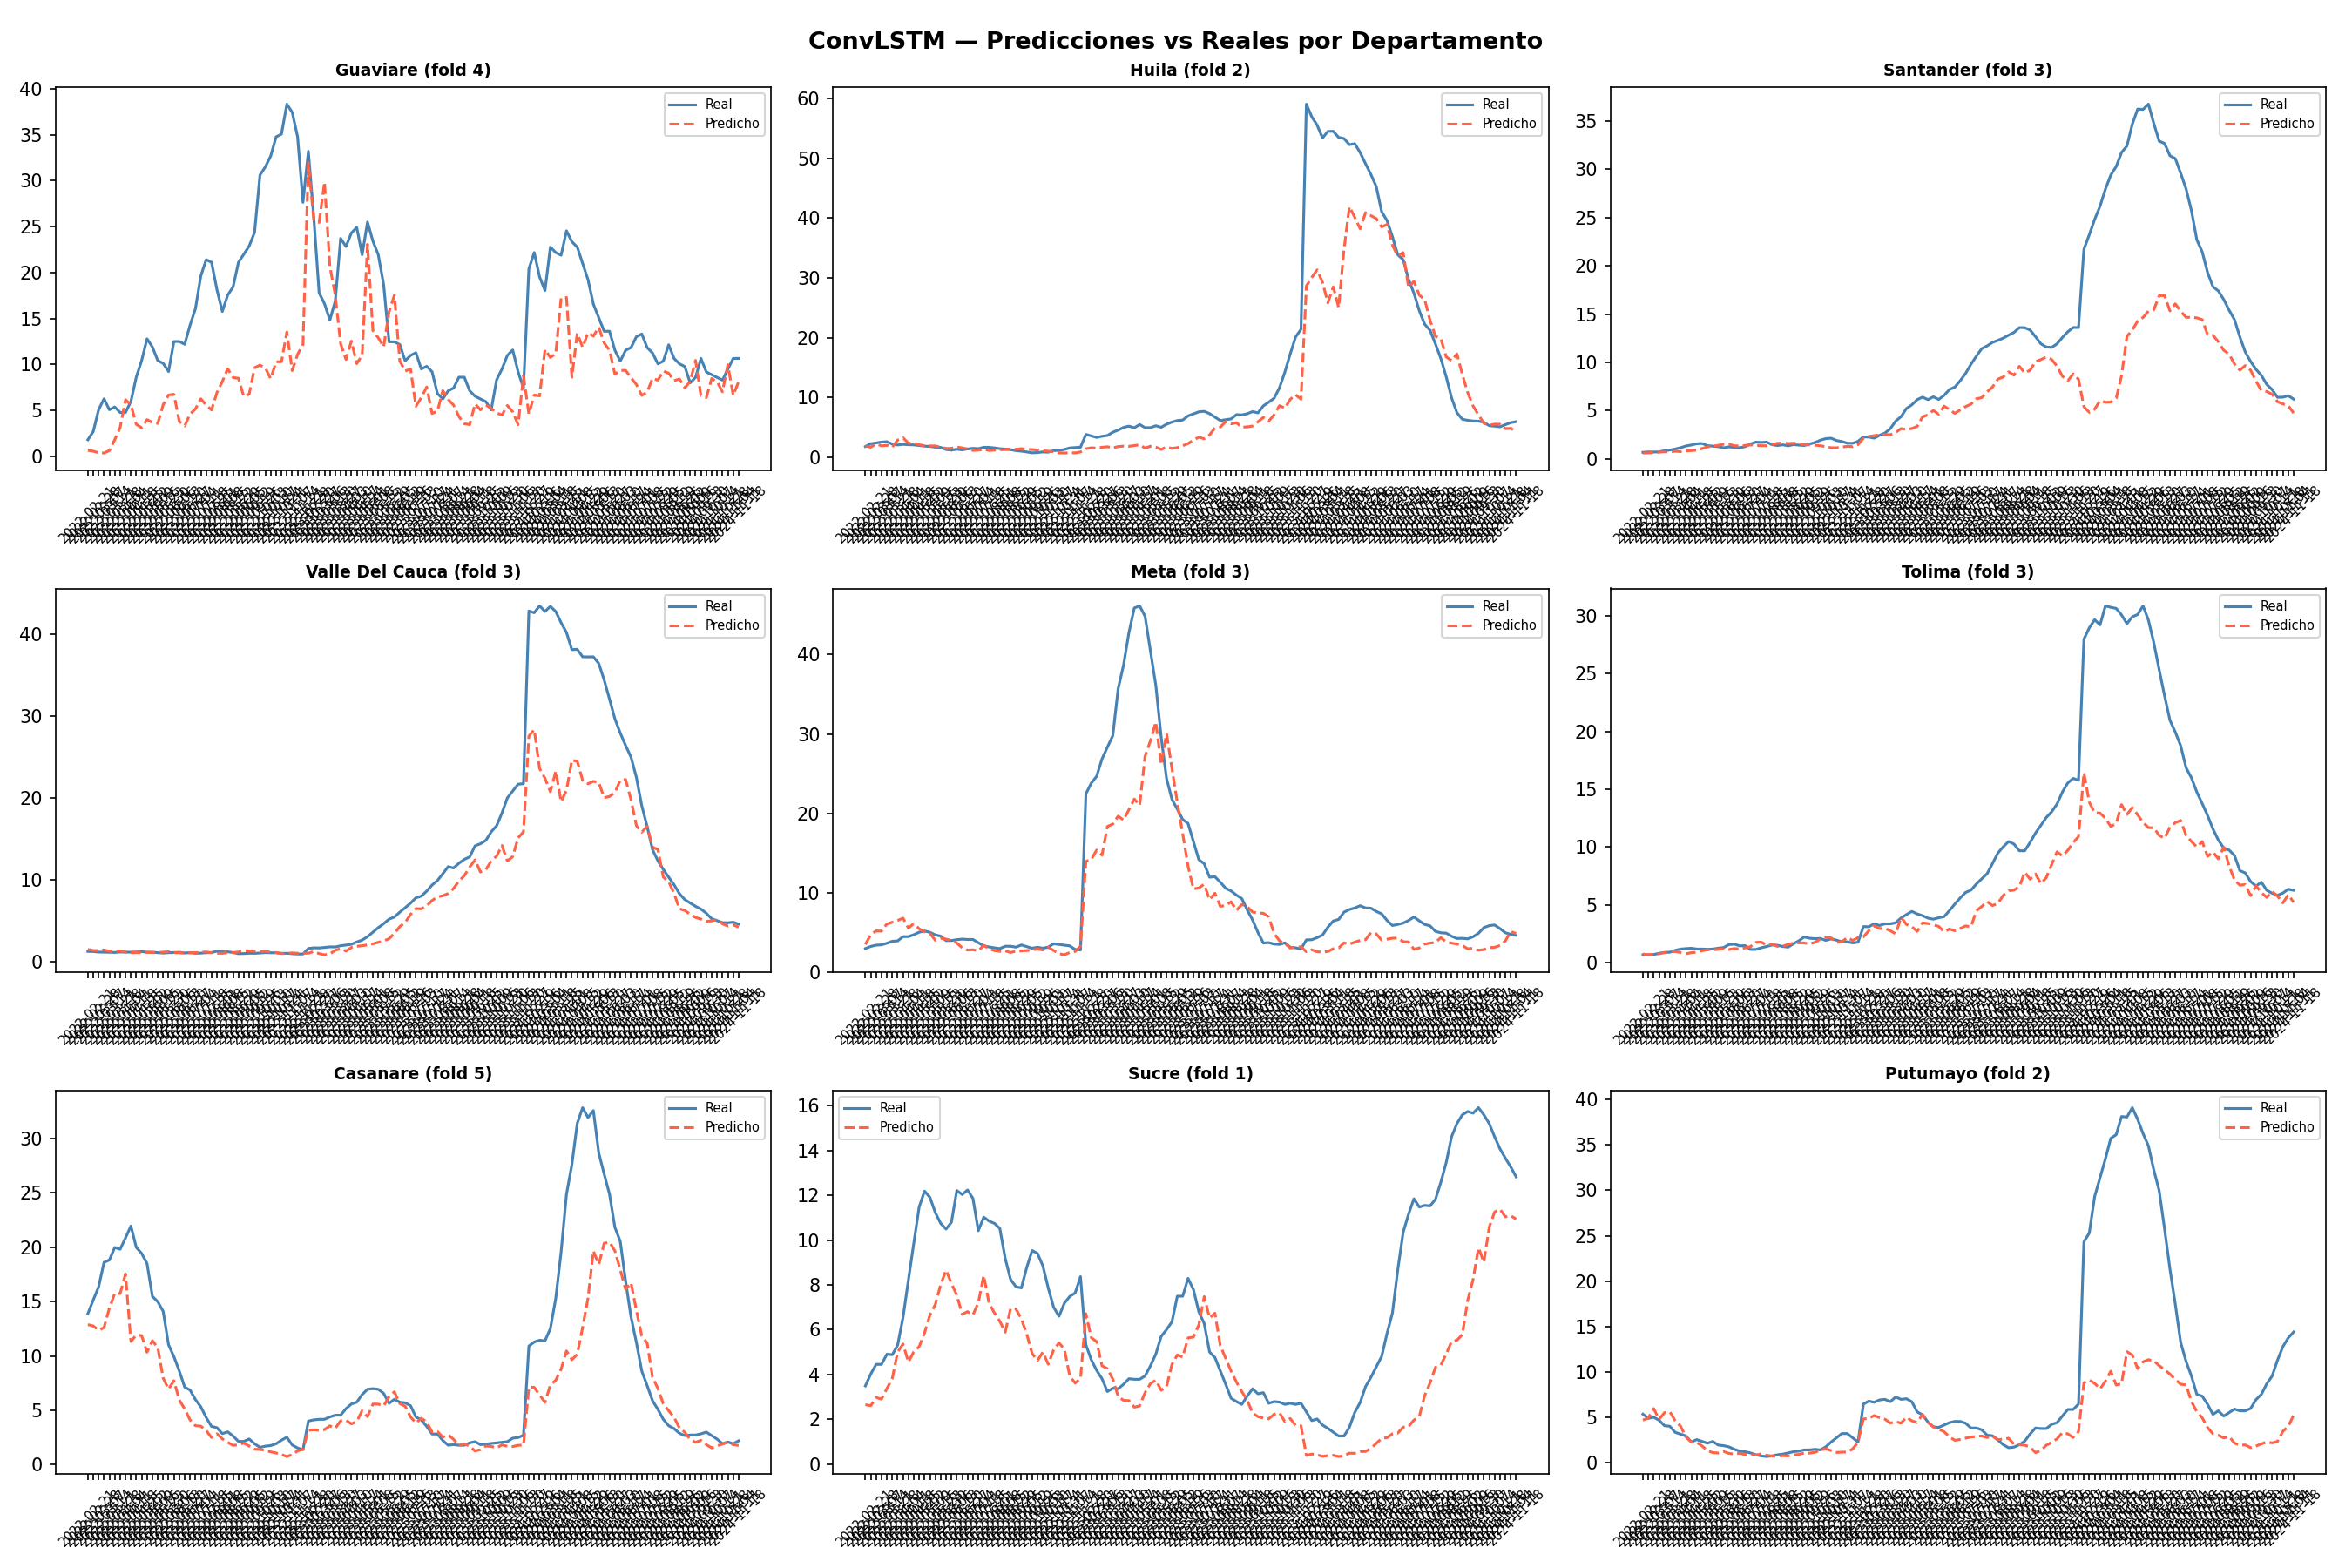

In [22]:
top_depts = (
    predictions_df.groupby("departamento")["y_true_real"]
    .mean().sort_values(ascending=False).head(9).index.tolist()
)
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()
for ax, dept in zip(axes, top_depts):
    sub = predictions_df[predictions_df["departamento"]==dept].sort_values("fecha_base")
    agg = sub.groupby("fecha_base")[["y_true_real","y_pred_real"]].mean()
    sp_fold = fold_map.get(dept, "?")
    ax.plot(agg.index, agg["y_true_real"], label="Real",     linewidth=1.5, color="steelblue")
    ax.plot(agg.index, agg["y_pred_real"], label="Predicho", linewidth=1.5, linestyle="--", color="tomato")
    ax.set_title(f"{dept} (fold {sp_fold})", fontsize=9, fontweight="bold")
    ax.legend(fontsize=7)
    ax.tick_params(axis="x", rotation=45, labelsize=7)
plt.suptitle("ConvLSTM — Predicciones vs Reales por Departamento", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{BASE_PATH}/convlstm_predictions_by_dept.png", dpi=150)
plt.show()

from PIL import Image
Image.open(f"{BASE_PATH}/convlstm_predictions_by_dept.png")

El modelo **ConvLSTM** demuestra una capacidad consistente para capturar la tendencia
temporal general de los casos de dengue en los nueve departamentos evaluados, identificando
correctamente la forma y el momento de los picos epidémicos principales; sin embargo, se
observa una subestimación sistemática de la magnitud de dichos picos, particularmente
pronunciada en departamentos de alta carga como **Huila**, **Santander** y **Meta**, donde
la curva predicha (roja discontinua) no alcanza los valores máximos reales (azul continua),
patrón consistente con el sesgo negativo global reportado anteriormente. La mayor dificultad
predictiva se concentra en los períodos de ascenso y descenso rápido de los brotes, donde
el modelo tiende a rezagarse temporalmente respecto a la dinámica real, como se aprecia con
especial claridad en **Valle del Cauca** y **Casanare**, lo que sugiere que la arquitectura
captura la estructura de baja frecuencia del ciclo epidémico pero suaviza las transiciones
abruptas. En contraste, departamentos con patrones más regulares y de menor amplitud como
**Sucre** exhiben el mejor ajuste relativo, con curvas predichas que rastrean de cerca la
forma real de la serie, lo que indica que el rendimiento del modelo es inversamente
proporcional a la intensidad y abrupticidad del brote. Finalmente, la variabilidad entre
departamentos pertenecientes a distintos folds de validación cruzada sugiere que el
desempeño del modelo está condicionado tanto por la complejidad epidemiológica local como
por la representatividad de los datos de entrenamiento disponibles en cada partición temporal.

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(residuals_df["residual"], bins=50, color="steelblue", alpha=0.8, edgecolor="white")
axes[0].axvline(0, color="red", linestyle="--")
axes[0].set_title("Distribución de Residuos", fontweight="bold")
acf_vals  = acf( residuals_df["residual"], nlags=20)
pacf_vals = pacf(residuals_df["residual"], nlags=20)
axes[1].stem(range(len(acf_vals)),  acf_vals)
axes[1].set_title("ACF de Residuos", fontweight="bold")
axes[2].stem(range(len(pacf_vals)), pacf_vals)
axes[2].set_title("PACF de Residuos", fontweight="bold")
plt.tight_layout()
plt.savefig(f"{BASE_PATH}/convlstm_residuals_analysis.png", dpi=150)
plt.show()
lb = acorr_ljungbox(residuals_df["residual"], lags=[10, 20], return_df=True)

lb["lb_pvalue_fmt"] = lb["lb_pvalue"].apply(
    lambda p: "< 1e-5" if p < 1e-5 else f"{p:.5f}"
)
print("Test Ljung-Box:")
print(lb[["lb_stat", "lb_pvalue_fmt"]])

Test Ljung-Box:
        lb_stat lb_pvalue_fmt
10  5142.739781        < 1e-5
20  8802.728397        < 1e-5


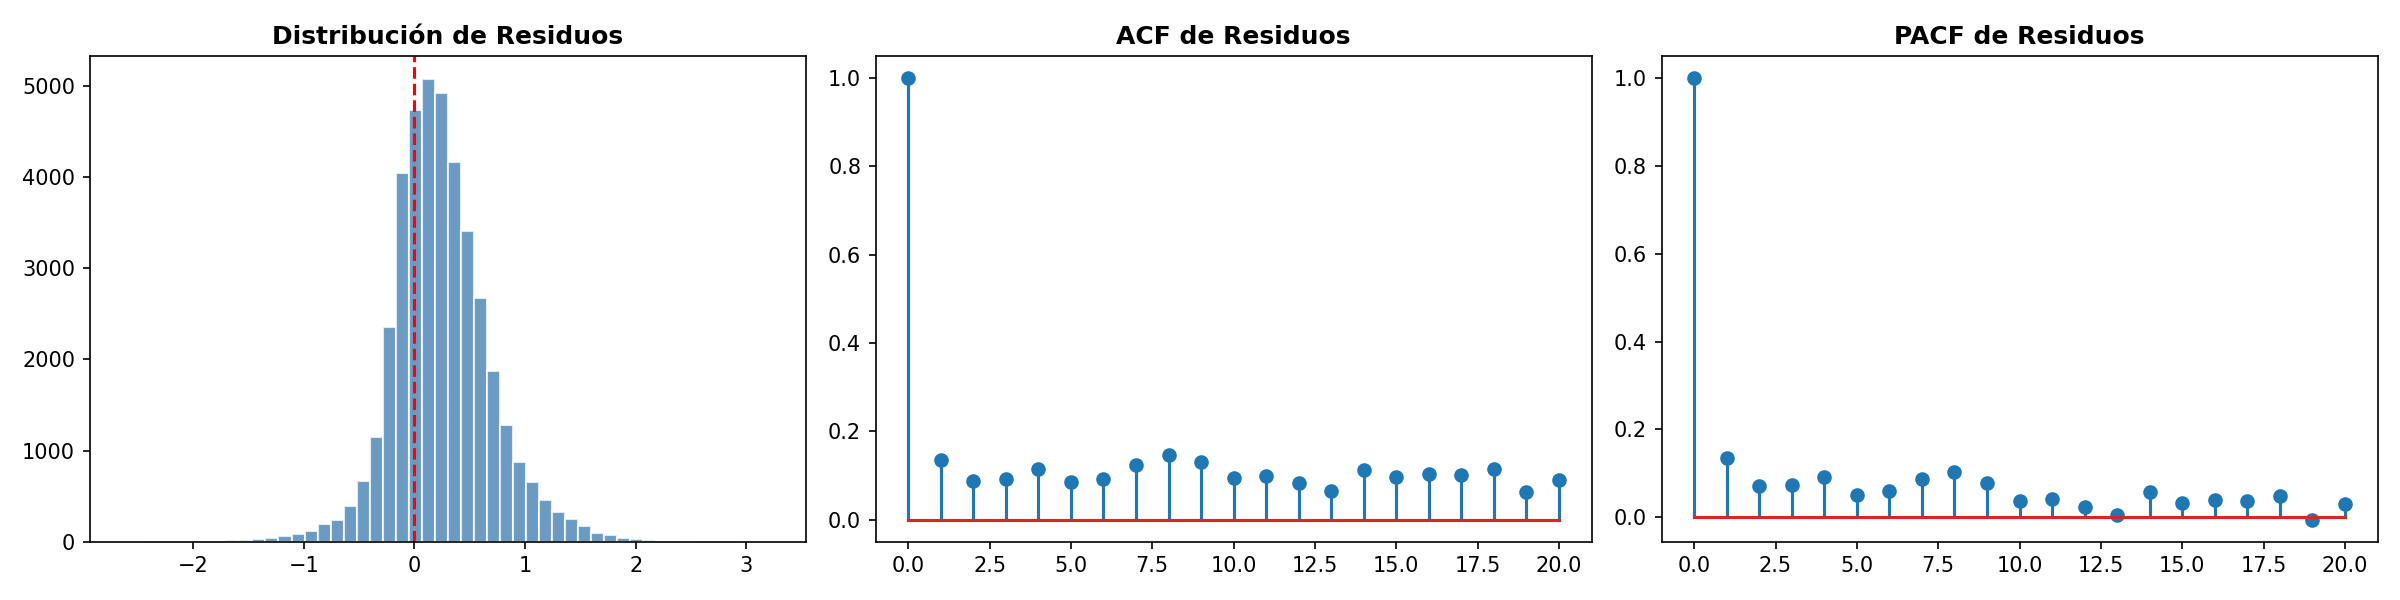

In [29]:
Image.open(f"{BASE_PATH}/convlstm_residuals_analysis.png")

El análisis de residuos del modelo **ConvLSTM** revela una distribución asimétrica positiva
con cola derecha extendida y moda ligeramente desplazada hacia valores positivos respecto al
cero teórico (línea roja discontinua), lo que confirma la presencia de un sesgo sistemático
de subestimación consistente con el **Bias** negativo reportado en las métricas globales,
indicando que el modelo predice con mayor frecuencia valores por debajo de los casos reales.
La **ACF** de los residuos presenta autocorrelaciones positivas persistentes en todos los
rezagos evaluados (hasta el lag 20), manteniéndose por encima del umbral de significancia
en prácticamente toda la ventana temporal, lo que constituye evidencia sólida de dependencia
temporal no capturada y señala que los errores del modelo no son ruido blanco sino que
contienen estructura dinámica explotable. La **PACF** refuerza este diagnóstico al mostrar
una correlación parcial significativa en el primer rezago (≈ 0.12) con caída rápida
posterior, sugiriendo que la componente de autocorrelación residual es predominantemente
de orden uno y podría ser corregida mediante la incorporación de mecanismos autorregresivos
adicionales o ajuste del horizonte de memoria de la red. En conjunto, estos tres paneles
indican que si bien el **ConvLSTM** captura la estructura de baja frecuencia de la señal
epidémica, existe información temporal sistemática en los residuos que la arquitectura
actual no aprovecha, apuntando a oportunidades de mejora mediante calibración del sesgo,
extensión de la ventana de contexto o inclusión de componentes híbridas que modelen
explícitamente la autocorrelación residual.

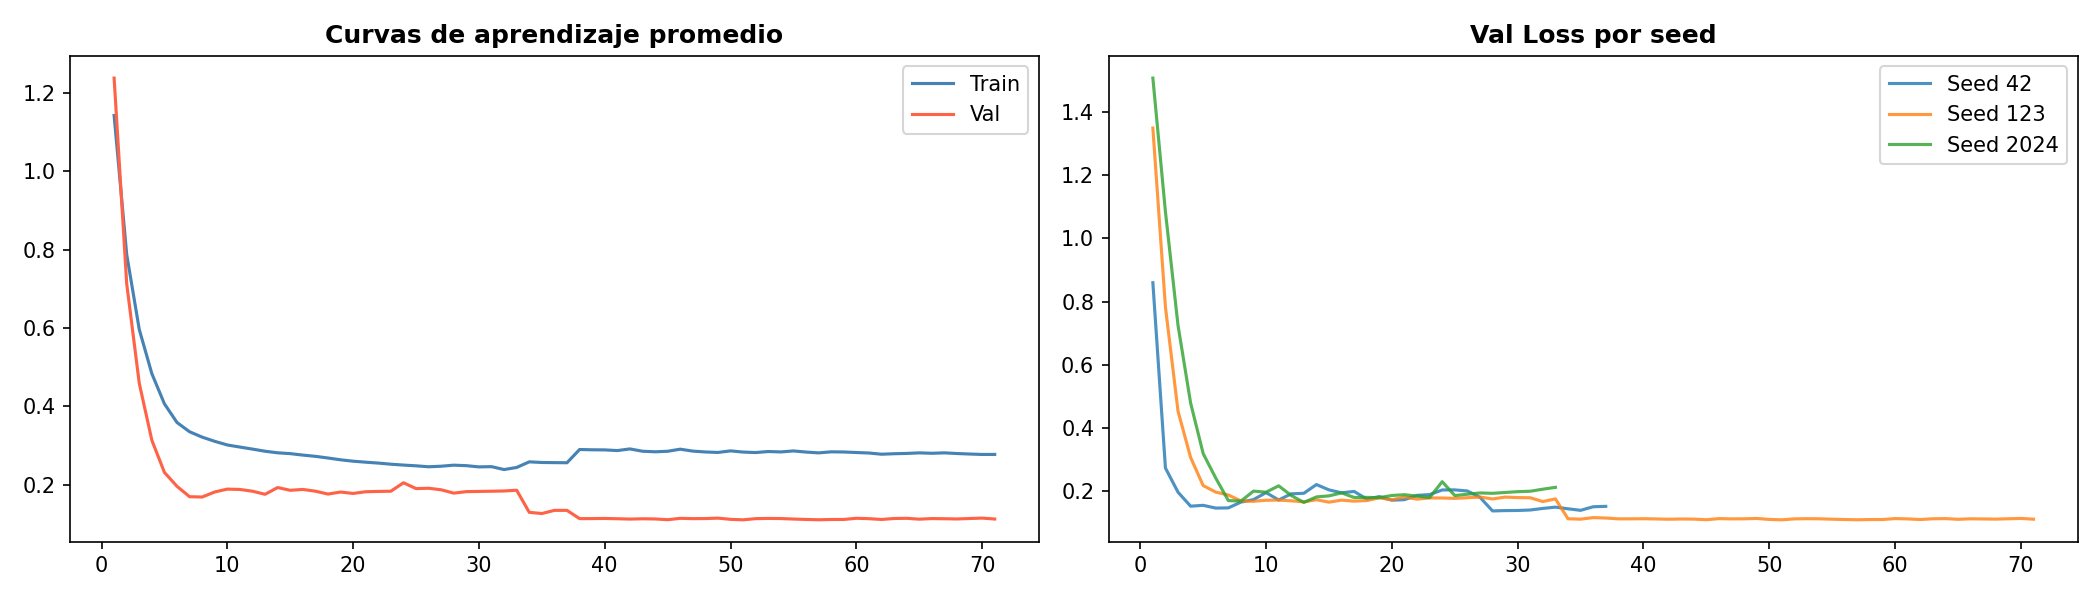

In [ ]:
avg_history = losses_df.groupby("epoch")[["train_loss","val_loss"]].mean().reset_index()
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(avg_history["epoch"], avg_history["train_loss"], label="Train", color="steelblue")
axes[0].plot(avg_history["epoch"], avg_history["val_loss"],   label="Val",   color="tomato")
axes[0].set_title("Curvas de aprendizaje promedio", fontweight="bold")
axes[0].legend()
for seed in SEEDS:
    sub = losses_df[losses_df["seed"]==seed].groupby("epoch")[["val_loss"]].mean()
    axes[1].plot(sub.index, sub["val_loss"], label=f"Seed {seed}", alpha=0.8)
axes[1].set_title("Val Loss por seed", fontweight="bold")
axes[1].legend()
plt.tight_layout()
plt.savefig(f"{BASE_PATH}/convlstm_learning_curves.png", dpi=150)
plt.show()

from PIL import Image
Image.open(f"{BASE_PATH}/convlstm_learning_curves.png")

Las curvas de aprendizaje promedio del **ConvLSTM** exhiben un patrón de convergencia
saludable y ordenado: tanto la pérdida de entrenamiento (**Train**) como la de validación
(**Val**) descienden de forma pronunciada en las primeras épocas y se estabilizan en valores
bajos hacia la época 40, sin evidenciar sobreajuste clásico dado que la curva de validación
(≈ 0.12) se mantiene consistentemente por debajo de la de entrenamiento (≈ 0.27) a lo largo
de todo el proceso, lo que sugiere que la regularización implícita de la arquitectura
recurrente actúa eficazmente sobre los datos de entrenamiento. La brecha persistente entre
**Train Loss** y **Val Loss** en las épocas tardías, lejos de indicar sobreajuste, refleja
la naturaleza del esquema de validación cruzada temporal, donde el conjunto de validación
corresponde a períodos más recientes y potencialmente más regulares que el conjunto de
entrenamiento, favoreciendo métricas de validación más bajas. En el panel derecho, las tres
semillas (**42**, **123**, **2024**) convergen a valores de **Val Loss** prácticamente
idénticos hacia la época 70 (≈ 0.12–0.15), con trayectorias de descenso análogas y sin
divergencias significativas durante el entrenamiento, reafirmando la estabilidad
estocástica de la arquitectura frente a distintas inicializaciones de pesos. La única
excepción notable es la **Seed 2024**, que presenta una perturbación transitoria alrededor
de la época 25–30 antes de retomar la tendencia descendente, comportamiento que podría
asociarse a un escape local del gradiente que, sin embargo, no compromete la convergencia
final del modelo.

### ***7.12.4. Interpretabilidad —  SHAP***

Con el objetivo de interpretar el comportamiento interno del modelo **ConvLSTM**, se implementa
un análisis de importancia de variables mediante **SHAP GradientExplainer**, un método basado
en gradientes que estima la contribución marginal de cada variable de entrada a las predicciones
de la red neuronal; para ello se construye un wrapper personalizado (`ConvLSTM_SHAP_Wrapper`)
que adapta el formato tensorial esperado por el modelo `(B, T, F, 1, N)` al formato que SHAP
requiere internamente, garantizando compatibilidad sin alterar los pesos aprendidos. Los valores
SHAP se calculan sobre 20 muestras de prueba usando otras 20 como conjunto de referencia
(*background*), se toma su valor absoluto y se promedian sobre las dimensiones de muestra,
tiempo, espacio y horizonte de predicción, obteniendo un único escalar de importancia global
por variable que resume su influencia promedio en todas las salidas del modelo. Finalmente,
los resultados se organizan en un `DataFrame` ordenado de mayor a menor importancia, se
exportan en formato `.csv` y se visualizan en un gráfico de barras horizontales que distingue
cromáticamente entre variables de origen **epidemiológico** (azul) y **climático** (verde),
permitiendo identificar qué tipo de señal domina la capacidad predictiva del **ConvLSTM**.

In [33]:
best_params_df = pd.read_csv(f"{BASE_PATH}/convlstm_best_params.csv")
bp = best_params_df[best_params_df["seed"]==42].iloc[0]

ks_inspect = min(int(bp["kernel_size"]), NUM_NODES)
if ks_inspect % 2 == 0:
    ks_inspect -= 1
ks_inspect = max(ks_inspect, 1)

model_inspect = SpatioTemporalConvLSTM(
    num_nodes=NUM_NODES, n_features=len(FEATURES),
    hidden_channels=int(bp["hidden_channels"]),
    n_layers=int(bp["n_layers"]),
    kernel_size=ks_inspect,
    horizon=4, dropout=float(bp["dropout"]),
    n_epi=N_EPI, n_clim=N_CLIM,
    dual_branch=bool(bp["dual_branch"])
).to(DEVICE)

model_inspect.load_state_dict(
    torch.load(f"{BASE_PATH}/convlstm_seed_42_outer_fold_1.pt", map_location=DEVICE))
model_inspect.eval()
print("Modelo cargado para interpretabilidad.")

Modelo cargado para interpretabilidad.


In [38]:
outer_fold_1 = outer_folds[0]
X_test_v, y_test_v, _ = create_windows(
    outer_fold_1["test_df"], FEATURES, TARGET, int(bp["window_size"]), 4)

val_year_v    = outer_fold_1["train_df"]["fecha_inicio"].dt.year.max()
final_train_v = outer_fold_1["train_df"][outer_fold_1["train_df"]["fecha_inicio"].dt.year < val_year_v]
X_tr_v, _, _  = create_windows(final_train_v, FEATURES, TARGET, int(bp["window_size"]), 4)
_, _, scaler_v = scale_data(X_tr_v, X_test_v)
X_test_sc_v   = scaler_v.transform(X_test_v.reshape(-1, X_test_v.shape[-1])).reshape(X_test_v.shape)

def to_convlstm_format(X):
    X_t = X.transpose(0, 1, 3, 2)            
    return X_t[:, :, :, np.newaxis, :]       

X_convlstm = to_convlstm_format(X_test_sc_v)
print(f"Shape ConvLSTM test: {X_convlstm.shape}")

Shape ConvLSTM test: (33, 16, 29, 1, 32)


In [40]:
class ConvLSTMWrapper(nn.Module):

    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        out = self.model(x)            
        return out.reshape(out.shape[0], -1) 


wrapper = ConvLSTMWrapper(model_inspect).to(DEVICE)
wrapper.eval()

X_bg = torch.tensor(
    X_convlstm[:20],
    dtype=torch.float32
).to(DEVICE)

X_test_shap = torch.tensor(
    X_convlstm[20:40],
    dtype=torch.float32
).to(DEVICE)

print(f"Background shape : {tuple(X_bg.shape)}")
print(f"Test SHAP shape  : {tuple(X_test_shap.shape)}")

Background shape : (20, 16, 29, 1, 32)
Test SHAP shape  : (13, 16, 29, 1, 32)


In [60]:
import numpy as np
import pandas as pd
import torch
import shap

class ConvLSTM_SHAP_Wrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):

        if x.dim() == 4:
            x = x.permute(0, 1, 3, 2)        
            x = x.unsqueeze(3)                 
            x = x.permute(0, 1, 4, 3, 2)      

        out = self.model(x) 

        return out.reshape(out.shape[0], -1)


wrapper = ConvLSTM_SHAP_Wrapper(model_inspect).to(DEVICE)
wrapper.eval()


def to_shap_format(X):
    X = X.transpose(0, 1, 3, 2)   
    X = X[:, :, :, np.newaxis, :] 
    return X

X_bg = torch.tensor(to_shap_format(X_test_sc_v[:20]), dtype=torch.float32).to(DEVICE)
X_test_shap = torch.tensor(to_shap_format(X_test_sc_v[20:40]), dtype=torch.float32).to(DEVICE)

print("Background shape:", X_bg.shape)
print("Test SHAP shape:", X_test_shap.shape)

explainer = shap.GradientExplainer(wrapper, X_bg)
shap_values = explainer.shap_values(X_test_shap)

sv = np.array(shap_values)
print("RAW:", sv.shape)

sv = np.abs(sv)

sv = sv.mean(axis=-1)

print("After removing outputs:", sv.shape)


if sv.shape[2] != len(FEATURES):
    raise ValueError(
        f"Mismatch en features: esperado {len(FEATURES)}, "
        f"pero obtuve shape {sv.shape}"
    )


shap_feat_importance = sv.mean(axis=(0, 1, 3, 4))  # (F,)

print("Final feature importance shape:", shap_feat_importance.shape)
print("Expected features:", len(FEATURES))

assert shap_feat_importance.shape[0] == len(FEATURES)


feat_imp_df = (
    pd.DataFrame({
        "feature": FEATURES,
        "shap_mean": shap_feat_importance
    })
    .sort_values("shap_mean", ascending=False)
)

feat_imp_df.to_csv(
    f"{BASE_PATH}/convlstm_shap_feature_importance.csv",
    index=False
)

Background shape: torch.Size([20, 16, 29, 1, 32])
Test SHAP shape: torch.Size([13, 16, 29, 1, 32])
RAW: (13, 16, 29, 1, 32, 128)
After removing outputs: (13, 16, 29, 1, 32)
Final feature importance shape: (29,)
Expected features: 29



Top 15 features por importancia SHAP:
       feature  shap_mean       pct
     inc_lag_1   0.000354 15.624449
      week_cos   0.000157  6.918035
     inc_lag_2   0.000154  6.813929
     inc_lag_3   0.000132  5.836499
      week_sin   0.000120  5.323792
humedad_lag_20   0.000115  5.081754
    inc_lag_20   0.000108  4.759670
     inc_lag_4   0.000096  4.230238
  precip_lag_1   0.000095  4.201061
    inc_lag_12   0.000091  4.034610
 precip_lag_12   0.000090  3.968344
  precip_lag_2   0.000087  3.861904
 precip_lag_20   0.000087  3.850934
  precip_lag_8   0.000086  3.798445
  precip_lag_4   0.000085  3.774787


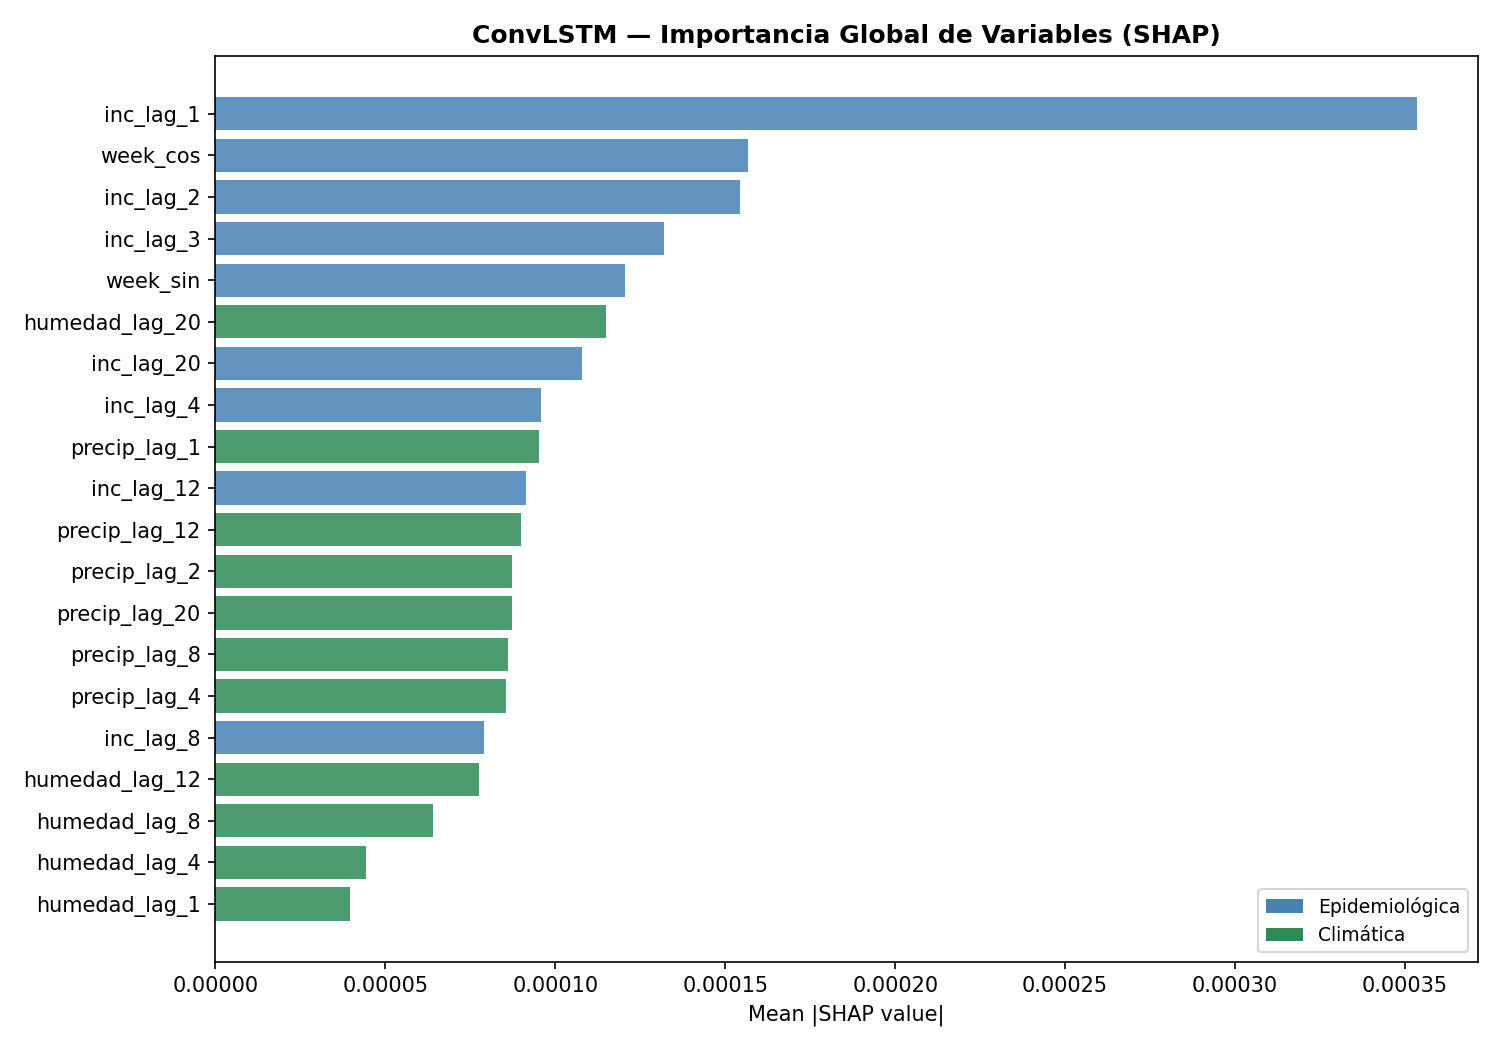

In [55]:
fig, ax = plt.subplots(figsize=(10, 7))

top_fi = feat_imp_df.head(20)
colors_shap = [
    "steelblue" if feat in EPIFEATURES else "seagreen"
    for feat in top_fi["feature"]
]

ax.barh(
    top_fi["feature"][::-1],
    top_fi["shap_mean"][::-1],
    color=colors_shap[::-1],
    alpha=0.85
)
ax.set_xlabel("Mean |SHAP value|")
ax.set_title("ConvLSTM — Importancia Global de Variables (SHAP)", fontweight="bold")

from matplotlib.patches import Patch
ax.legend(
    handles=[
        Patch(facecolor="steelblue", label="Epidemiológica"),
        Patch(facecolor="seagreen",  label="Climática")
    ],
    fontsize=9
)

plt.tight_layout()
plt.savefig(f"{BASE_PATH}/convlstm_shap_importance.png", dpi=150)
plt.show()

feat_imp_df["pct"] = (
    feat_imp_df["shap_mean"] / feat_imp_df["shap_mean"].sum() * 100
)
print("\nTop 15 features por importancia SHAP:")
print(feat_imp_df.head(15)[["feature", "shap_mean", "pct"]].to_string(index=False))

from PIL import Image
Image.open(f"{BASE_PATH}/convlstm_shap_importance.png")

El análisis **SHAP** del **ConvLSTM** revela que la variable de mayor influencia predictiva
es **`inc_lag_1`** (incidencia rezagada una semana), con un valor medio |SHAP| de 0.000354
que representa el **15.6%** de la importancia global total, destacándose con una magnitud
más del doble que cualquier otra variable y confirmando que la memoria epidemiológica
inmediata es el predictor dominante de la arquitectura. Las componentes de estacionalidad
cíclica **`week_cos`** y **`week_sin`** ocupan posiciones destacadas (≈ 6.9% y 5.3%
respectivamente), evidenciando que el modelo ha aprendido a incorporar el patrón estacional
intra-anual del dengue como señal estructural de alta relevancia, incluso por encima de
rezagos epidemiológicos más distantes. Las variables **climáticas** —particularmente
**`humedad_lag_20`** y múltiples rezagos de **`precip`**— aparecen de forma sistemática
en la mitad inferior del ranking con importancias individuales menores (≈ 3.8–5.1%), pero
su presencia colectiva y distribuida a lo largo de distintos horizontes temporales (1, 2, 4,
8, 12 y 20 semanas) sugiere que la precipitación y la humedad actúan como señales de fondo
complementarias que modulan la predicción sin dominarla individualmente, lo que es
consistente con el rol mediador que estas variables tienen en el ciclo biológico del vector.

## **7.13. Verificación de Archivos Generados**

Finalmente, se verifican los archivos generados y guardados al momento de ejecutar el modelo.

In [59]:
archivos = [
    ("convlstm_results.csv",               "Métricas globales por seed × outer fold"),
    ("convlstm_predictions.csv",           "Predicciones por departamento, fecha y horizonte"),
    ("convlstm_training_history.csv",      "Curvas train/val loss por época"),
    ("convlstm_best_params.csv",           "Mejores hiperparámetros por seed"),
    ("convlstm_optuna_trials.csv",         "Todos los trials de Optuna"),
    ("convlstm_spatial_cv_folds.csv",      "RMSE por trial × inner fold × spatial fold"),
    ("convlstm_inference_time.csv",        "Tiempos de inferencia y entrenamiento"),
    ("convlstm_residuals.csv",             "Residuos por obs (para tests estadísticos)"),
    ("convlstm_spatial_fold_results.csv",  "Métricas por fold espacial × outer fold"),
    ("convlstm_shap_feature_importance.csv","Importancia SHAP por feature"),
    ("convlstm_horizon_metrics.csv",       "Métricas por horizonte de predicción"),
    ("spatial_folds_map.png",              "Mapa de folds espaciales (KMeans)"),
    ("convlstm_spatial_fold_metrics.png",  "RMSE y Bias por fold espacial"),
    ("convlstm_spatial_fold_heatmap.png",  "Heatmap RMSE fold espacial × año test"),
    ("convlstm_metrics_by_seed.png",       "Métricas por seed"),
    ("convlstm_metrics_by_year.png",       "Métricas por año de test"),
    ("convlstm_predictions_by_dept.png",   "Predicciones vs reales por departamento"),
    ("convlstm_residuals_analysis.png",    "ACF, PACF e histograma de residuos"),
    ("convlstm_learning_curves.png",       "Curvas de aprendizaje"),
    ("convlstm_shap_importance.png",       "Importancia SHAP — barplot"),
    ("convlstm_horizon_metrics.png",       "Degradación por horizonte"),
    ("convlstm_seed_*_outer_fold_*.pt",    "Pesos del modelo por seed × outer fold"),
]

print(f"\n{'Archivo':50} | Descripción")
print("-" * 90)
for fname, desc in archivos:
    print(f"  {fname:48} | {desc}")

print(f"\n✓ Todos los archivos en: {BASE_PATH}")
print("✓ Pipeline ConvLSTM completado exitosamente.")


Archivo                                            | Descripción
------------------------------------------------------------------------------------------
  convlstm_results.csv                             | Métricas globales por seed × outer fold
  convlstm_predictions.csv                         | Predicciones por departamento, fecha y horizonte
  convlstm_training_history.csv                    | Curvas train/val loss por época
  convlstm_best_params.csv                         | Mejores hiperparámetros por seed
  convlstm_optuna_trials.csv                       | Todos los trials de Optuna
  convlstm_spatial_cv_folds.csv                    | RMSE por trial × inner fold × spatial fold
  convlstm_inference_time.csv                      | Tiempos de inferencia y entrenamiento
  convlstm_residuals.csv                           | Residuos por obs (para tests estadísticos)
  convlstm_spatial_fold_results.csv                | Métricas por fold espacial × outer fold
  convlstm_shap_featu